# E: AMN growth and MINN flux transfer

One frozen E FluxTransformer is shared across independently trained front MLPs. AMN uses a medium-to-growth MLP. MINN trains two independent omics-to-context MLPs: measured and predicted glucose/oxygen context. Each outer fold starts a fresh MLP. Both MINN variants use observed glucose/oxygen bounds in downstream pFBA.

The notebook contains no generic tabular-model benchmark. Run from the repository root using its Python environment. The local model E checkpoint is configured below; command provenance is optional. MINN runs one 50-trial, five-fold HPO study per context mode, then 29 leave-one-out fits with the selected parameters. The final pFBA table compares the original MINN fit with an iML1515-fitted sensitivity test. The latter retrains the measured-context MLP on its own fitted file. New results remain empty until you execute the notebook.

Implementation helpers: `iml1515_evaluation.py`. Protocol: `docs/experiment_notes/iML1515_sampling_study_notes.md`. Historical A/B/C scores require matched reruns before comparison.

In [1]:
import os
import numpy as np
import seaborn as sns
from pathlib import Path
from datetime import datetime, timezone
import importlib.metadata
import subprocess

import pandas as pd
import matplotlib.pyplot as plt
import torch
from IPython.display import display

import iml1515_evaluation as ev
from importlib import reload
ev = reload(ev)  # Pick up evaluator changes when rerunning in an existing kernel.

ROOT = Path.cwd()
if not (ROOT / "flux_transformer.py").is_file():
    raise RuntimeError("Start the notebook in the metabolic-NN repository root.")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cuda


## Run configuration

The local model E checkpoint, training log and biomass test CSV are selected below. Run the notebook from the repository root. Generation/training command fields are optional documentation and may remain empty. A missing optional log or biomass CSV does not prevent AMN/MINN evaluation.

The checkpoint loss curves and biomass-only diagnostic appear before experimental training. Full A/B simulated fidelity is disabled by default; enable it only when you want that additional analysis and have set its test paths. Optional extra MINN target-file and cap-set sensitivities retain both context modes. The separate iML1515-fitted test runs measured context only and is enabled by default.

In [2]:
MODEL_FAMILY = "E"
CHECKPOINT = ROOT / "models/E_1M_d256_h8_l4_ff1024/E_1M_d256_h8_l4_ff1024_checkpoint.pth"
TRAINING_LOG = ROOT / "models/E_1M_d256_h8_l4_ff1024/E_1M_d256_h8_l4_ff1024_training.log"
METADATA_JSON = None  # Only needed if the checkpoint lacks config/data_info.
TRAINING_PROVENANCE = {"generation_command": "", "training_command": "", "seed": 42}

RUN_SIMULATED = False  # Optional full A/B fidelity analysis.
BIOMASS_TEST_PATH = ROOT / "data/iML1515_E_test_data_50000_samples.csv"
BIOMASS_BATCH_SIZE = 2
RUN_AMN = True
RUN_MINN = True
RUN_IML1515_FIT_SENSITIVITY = True  # Retrain measured MINN context on the iML1515-fitted file.
TARGET_MODES = ["minn_fitted"]  # Optional additional full two-mode sensitivity: "non_fitted".
CAP_MODES = ["co2_etoh_ac_cap"]  # Optional additional sensitivity: "etoh_ac_cap".
SIMULATED = {
    "A": {"path": None, "seed": 9, "rows": 50000, "command": ""},
    "B": {"path": None, "seed": 9, "rows": 50000, "command": ""},
}
SIM_BATCH_SIZE = 2
OBJECTIVE_CHECK_SAMPLES = 100  # First 100 rows/domain
# All rows get mass/bound checks.
PFBA_FRACTION = 1.0  # Match the original MINN downstream pFBA.
XML_PATH = ROOT / "models/iML1515.xml"
AMN_DIR, MINN_DIR = ROOT / "AMN_data", ROOT / "MINN_data"

AMN_SETTINGS = dict(folds=10, split_seeds=[10, 11, 12], train_seed=10,
    validation_protocol="legacy_outer_early_stopping", hidden=512, epochs=100, patience=15, min_delta=0.0,
    batch_size=1, validation_batch_size=2, delta=0.03, clip=None, amp=False, warmup=0,
    params={"drop_rate": 0.0, "learning_rate": 1e-3, "weight_decay": 1e-3})
MINN_SETTINGS = dict(legacy_protocol=True, seed=12345, inner_folds=5, trials=50, hidden=512,
    epochs=150, patience=25, min_delta=1e-5, batch_size=2 if DEVICE.type == "cuda" else 5, delta=1.0,
    clip=1.0, amp=DEVICE.type == "cuda", warmup=10, std_penalty=0.25,
    drop_rates=[0.0, 0.05, 0.1, 0.2, 0.3, 0.35, 0.4],
    lr_range=[5e-4, 1e-2], wd_range=[1e-8, 1e-3])
# Use a new directory for every execution
# Completed folds are saved immediately.
RUN_ID = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")


In [3]:
required = {"CHECKPOINT": CHECKPOINT, "XML": XML_PATH}
if TRAINING_LOG is not None and Path(TRAINING_LOG).is_file():
    required["TRAINING_LOG"] = TRAINING_LOG
if BIOMASS_TEST_PATH is not None and Path(BIOMASS_TEST_PATH).is_file():
    required["biomass_test"] = BIOMASS_TEST_PATH
if METADATA_JSON is not None:
    required["METADATA_JSON"] = METADATA_JSON
if RUN_AMN:
    required.update({name: AMN_DIR / name for name in ("iML1515_EXP.csv", "EXP110.csv")})
if RUN_MINN:
    if "minn_fitted" not in TARGET_MODES or "iml1515_minn_like" in TARGET_MODES or len(set(TARGET_MODES)) != len(TARGET_MODES):
        raise ValueError("Keep minn_fitted in TARGET_MODES; the iML1515 fit has a separate measured-only test.")
    if "co2_etoh_ac_cap" not in CAP_MODES or not set(CAP_MODES) <= {"co2_etoh_ac_cap", "etoh_ac_cap"}:
        raise ValueError("Keep the primary CO2/ethanol/acetate cap comparison enabled.")
    required.update({name: MINN_DIR / name for name in ("transcriptomics.csv", "proteomics.csv")})
    required.update({mode: MINN_DIR / ev.FLUX_FILES[mode] for mode in TARGET_MODES})
    if RUN_IML1515_FIT_SENSITIVITY:
        required["iml1515_fit_sensitivity"] = MINN_DIR / ev.FLUX_FILES["iml1515_minn_like"]
if RUN_SIMULATED:
    required.update({f"simulated_{key}": spec["path"] for key, spec in SIMULATED.items()})
missing = [name for name, path in required.items() if path is None or not Path(path).is_file()]
if missing:
    raise FileNotFoundError("Configure/provide these inputs before running: " + ", ".join(missing))
if RUN_SIMULATED and any(s["seed"] is not None and s["seed"] == TRAINING_PROVENANCE["seed"] for s in SIMULATED.values()):
    raise ValueError("Held-out generation seed must differ from the training seed.")

reservoir, input_names, output_names, architecture, training_info = ev.load_reservoir(CHECKPOINT, DEVICE, METADATA_JSON, model_family=MODEL_FAMILY)
model_name = Path(CHECKPOINT).parent.name
run_dir = ROOT / "pics" / model_name / "E_evaluation" / RUN_ID
run_dir.mkdir(parents=True, exist_ok=False)
pic_dir = run_dir / "figures"
pic_dir.mkdir()
print("Architecture:", architecture)
print("Inputs:", len(input_names), "Outputs:", len(output_names))
print("Artifacts:", run_dir)


Architecture: {'d_model': 256, 'n_heads': 8, 'n_layers': 4, 'd_ff': 1024, 'dropout': 0.02, 'batch_size': 32, 'learning_rate': 0.0001, 'num_epochs': 14, 'requested_num_epochs': 20, 'training_end_epoch': 18, 'patience': 4, 'vocab_size': 2712, 'input_token_indices': [180, 1981, 45, 1525, 106, 40, 86, 92, 104, 164, 304, 621, 700, 859, 913, 934, 970, 1424, 1478, 1485, 1500, 1534, 1535, 1836, 2243, 2320, 633, 211, 205, 101, 209, 206, 1439, 303, 81, 288, 631, 114, 120, 1437, 99, 494, 347, 88, 111, 112, 119, 1463, 627, 847, 90, 108, 98, 1490, 217], 'output_sample_ratio': 1.0}
Inputs: 55 Outputs: 2712
Artifacts: c:\Users\truok\projects\metabolic-NN\pics\E_1M_d256_h8_l4_ff1024\E_evaluation\20261001T052716734294Z


In [4]:
manifest = {
    "model_family": MODEL_FAMILY, "run_id": RUN_ID, "checkpoint": str(CHECKPOINT), "architecture": architecture,
    "training_info": training_info, "training_provenance": TRAINING_PROVENANCE,
    "inputs": input_names, "outputs": output_names, "device": str(DEVICE),
    "objective": ev.OBJECTIVE, "pfba_fraction": PFBA_FRACTION,
    "amn_settings": AMN_SETTINGS, "minn_settings": MINN_SETTINGS,
    "target_modes": TARGET_MODES, "cap_modes": CAP_MODES, "simulated_specs": SIMULATED,
    "iml1515_fit_sensitivity": RUN_MINN and RUN_IML1515_FIT_SENSITIVITY,
    "objective_check_samples": OBJECTIVE_CHECK_SAMPLES,
    "versions": {p: importlib.metadata.version(p) for p in ("torch", "numpy", "pandas", "scikit-learn", "cobra", "optuna")},
    "files": {name: {"path": str(path), "sha256": ev.file_hash(path)} for name, path in required.items()},
    "code_hashes": {name: ev.file_hash(ROOT / name) for name in
        ("iml1515_evaluation.py", "flux_transformer.py", "generate_ecoli_iML1515_E_data.py", "ecoli_iML1515_E_model_testing.ipynb")},
    "git_revision": subprocess.run(["git", "rev-parse", "HEAD"], capture_output=True, text=True).stdout.strip(),
    "status": "started", "deferred": ["broad E fidelity"],
}
ev.save_json(run_dir / "manifest.json", manifest)
# No automatic cache loading: fresh run directories prevent stale-mode/result reuse.
amn_result, minn_data, minn_results, pfba_results = None, {}, {}, {}
simulated_summary = None


## Checkpoint loss curves and biomass diagnostic

These use the same plotting functions and style as the earlier AMN notebook: a logarithmic loss graph and a 2?2 biomass diagnostic (true versus predicted, residuals, error distribution, and true-value distribution). The saved checkpoint calls its held-out loss `test_losses`; it is labelled Validation Loss here. Only biomass is plotted. Full-vocabulary inference is retained.


In [5]:
def plot_loss_curves(train_losses, test_losses, d_model, n_heads, n_layers, d_ff, save_path=None, log_scale=True):
    plt.figure(figsize=(14, 10))
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.plot(train_losses, label="Training Loss")
    plt.plot(test_losses, label="Validation Loss")
    if log_scale:
        plt.yscale('log')
    plt.xlabel("Epoch", fontsize=18)
    plt.ylabel("Loss", fontsize=18)
    plt.title(f"Loss Curves (d={d_model}, h={n_heads}, l={n_layers}, ff={d_ff})", fontsize=20)
    plt.grid(True)
    plt.legend(fontsize=16)
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path)
        plt.show()
        print(f"\nTraining curve saved to {save_path}")
    else:
        plt.show()

def plot_diagnostics_2x2(y_true, y_pred, label, save_path=None):
    """Creates a 2x2 matrix of plots: true vs predicted, residuals, error distribution, and histogram of samples."""
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    residuals = y_true - y_pred
    display_label = str(label)
    if display_label.endswith('_flux'):
        display_label = display_label[:-5]
    if display_label.upper().startswith('BIOMASS'):
        display_label = 'Model E iML1515 Biomass'

    title_fs = 15
    label_fs = 13
    tick_fs = 11

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    # True vs Predicted
    axs[0, 0].scatter(y_true, y_pred, alpha=0.2, s=5, color='royalblue')
    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())
    axs[0, 0].plot([lo, hi], [lo, hi], 'k--', lw=2)
    axs[0, 0].set_title(f'True vs Predicted: {display_label}', fontsize=title_fs)
    axs[0, 0].set_xlabel('True value', fontsize=label_fs)
    axs[0, 0].set_ylabel('Predicted', fontsize=label_fs)
    axs[0, 0].grid(True)

    # Residuals plot
    axs[0, 1].scatter(y_true, residuals, alpha=0.15, color='darkorange')
    axs[0, 1].axhline(y=0, color='r', linestyle='-')
    axs[0, 1].set_title(f'Residuals: {display_label}', fontsize=title_fs)
    axs[0, 1].set_xlabel('True value', fontsize=label_fs)
    axs[0, 1].set_ylabel('Residuals', fontsize=label_fs)
    if str(label).upper().startswith('BIOMASS'):
        axs[0, 1].set_ylim(-0.05, 0.05)
    else:
        res_abs_max = float(np.nanmax(np.abs(residuals))) if residuals.size else 1.0
        if (not np.isfinite(res_abs_max)) or (res_abs_max == 0.0):
            res_abs_max = 1.0
        axs[0, 1].set_ylim(-res_abs_max, res_abs_max)
    axs[0, 1].grid(True)

    # Error distribution
    sns.histplot(residuals, kde=True, ax=axs[1, 0], legend=False, color='indianred')
    axs[1, 0].set_title(f'Prediction Error Distribution: {display_label}', fontsize=title_fs)
    axs[1, 0].set_xlabel('Prediction Error', fontsize=label_fs)
    axs[1, 0].set_ylabel('Frequency', fontsize=label_fs)
    axs[1, 0].grid(True)

    # Histogram of actual values
    sns.histplot(y_true, kde=True, bins=100, ax=axs[1, 1], legend=False, color='mediumseagreen')
    axs[1, 1].set_title(f'True Value Distribution: {display_label}', fontsize=title_fs)
    axs[1, 1].set_xlabel('True Value', fontsize=label_fs)
    axs[1, 1].set_ylabel('Frequency', fontsize=label_fs)
    axs[1, 1].grid(True)

    for ax in axs.ravel():
        ax.tick_params(labelsize=tick_fs)

    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        plt.show()
        plt.close(fig)
    else:
        plt.show()
        plt.close(fig)

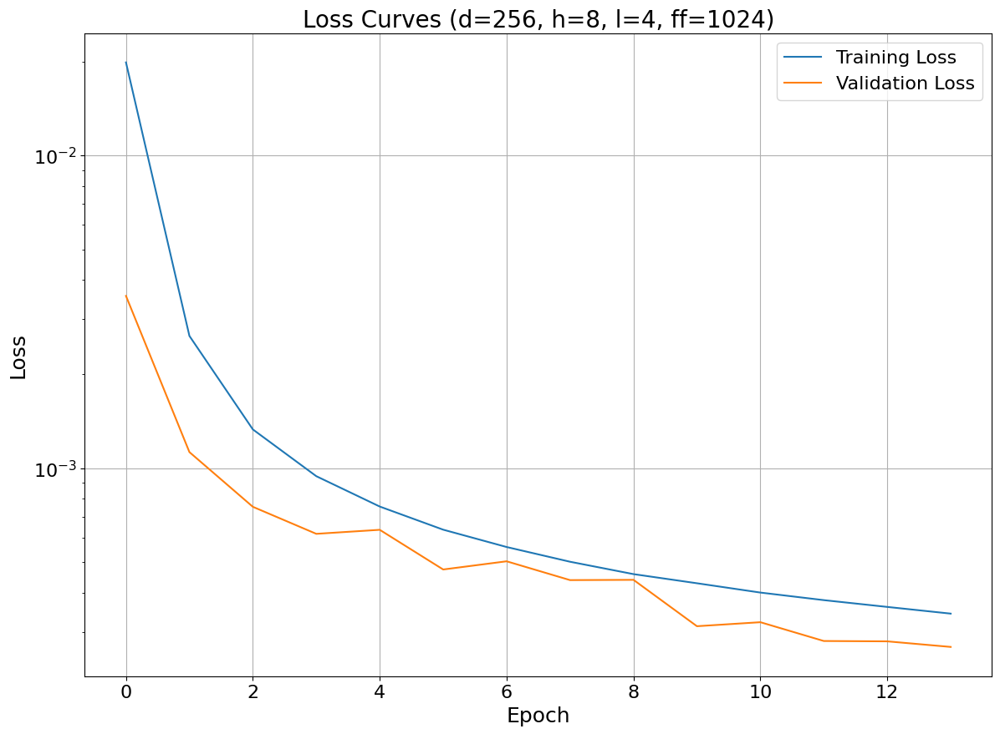


Training curve saved to c:\Users\truok\projects\metabolic-NN\pics\E_1M_d256_h8_l4_ff1024\E_evaluation\20261001T052716734294Z\figures\E_1M_d256_h8_l4_ff1024_loss_curves.png


In [6]:
checkpoint_plot_data = torch.load(CHECKPOINT, map_location="cpu", weights_only=False)
train_losses = checkpoint_plot_data.get("train_losses", [])
validation_losses = checkpoint_plot_data.get("test_losses", [])
del checkpoint_plot_data
if len(train_losses) and len(validation_losses):
    plot_loss_curves(train_losses, validation_losses,
        architecture["d_model"], architecture["n_heads"], architecture["n_layers"], architecture["d_ff"],
        save_path=str(pic_dir / f"{model_name}_loss_curves.png"))
else:
    print("Checkpoint has no saved loss history; loss plot skipped.")


,R2,Pearson_r2,MAE,RMSE,NE
0,0.995259,0.998034,0.007169,0.008487,0.043263


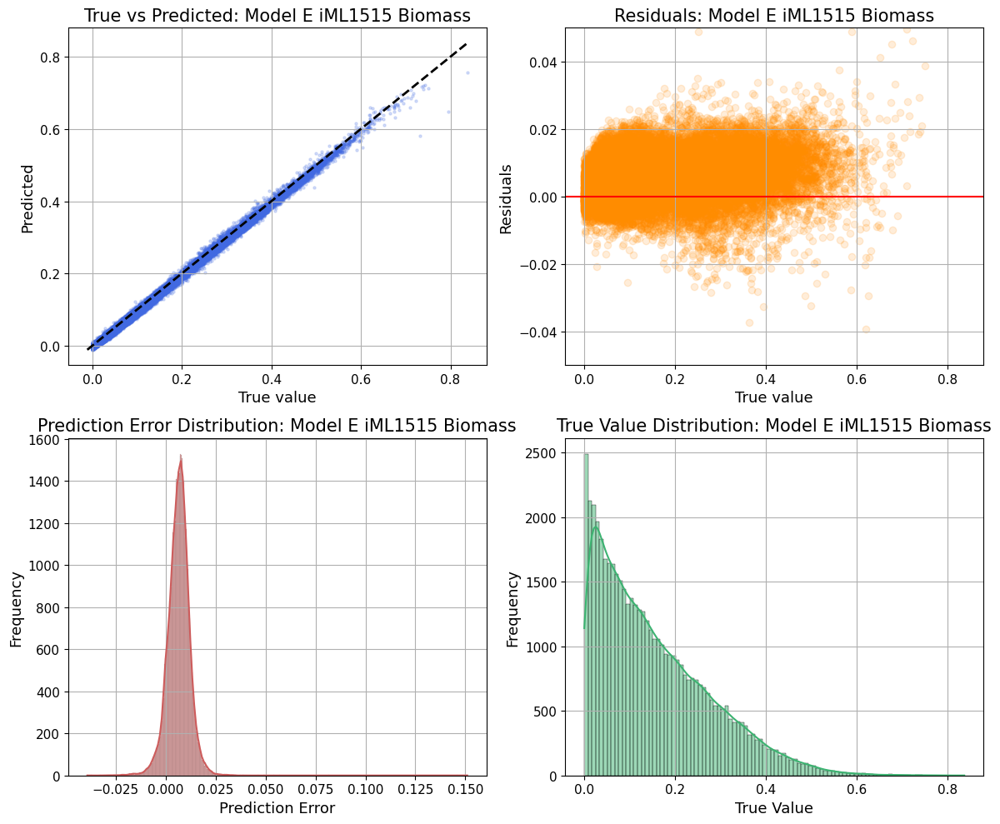

In [7]:
biomass_diagnostic = None
if BIOMASS_TEST_PATH is None or not Path(BIOMASS_TEST_PATH).is_file():
    print("Biomass diagnostic skipped: set BIOMASS_TEST_PATH to an independent simulated test CSV.")
else:
    if Path(BIOMASS_TEST_PATH).resolve() == Path(str(training_info.get("dataset", ""))).resolve():
        raise ValueError("Biomass diagnostics require held-out data, not the training CSV.")
    header = pd.read_csv(BIOMASS_TEST_PATH, nrows=0).columns.tolist()
    if [name for name in header if name.endswith("_flux")] != output_names:
        raise ValueError("Biomass test output order differs from the checkpoint.")
    if [name for name in header if not name.endswith("_flux")] != input_names:
        raise ValueError("Biomass test input order differs from the checkpoint.")
    biomass_token = f"{ev.OBJECTIVE}_flux"
    biomass_index = output_names.index(biomass_token)
    injection = [output_names.index(f"{name}_flux") for name in input_names]
    biomass_truth, biomass_prediction = [], []
    reservoir.eval()
    with torch.inference_mode():
        for frame in pd.read_csv(BIOMASS_TEST_PATH, usecols=input_names + [biomass_token], chunksize=128):
            ev.finite_frame(frame, "Biomass test data")
            medium = frame[input_names].to_numpy(np.float32)
            biomass_truth.extend(frame[biomass_token].to_numpy(float))
            for start in range(0, len(frame), BIOMASS_BATCH_SIZE):
                values = torch.as_tensor(medium[start:start + BIOMASS_BATCH_SIZE], device=DEVICE)
                c = torch.zeros(len(values), len(output_names), 1, device=DEVICE)
                c[:, injection, 0] = values
                predicted, _ = reservoir(c, output_subset=None)
                biomass_prediction.extend(predicted[:, biomass_index, -1].cpu().numpy())
    biomass_diagnostic = pd.DataFrame({"truth": biomass_truth, "prediction": biomass_prediction})
    display(pd.DataFrame([ev.metrics(biomass_truth, biomass_prediction)]))
    biomass_diagnostic.to_csv(run_dir / "biomass_diagnostic.csv", index=False)
    plot_diagnostics_2x2(biomass_truth, biomass_prediction, biomass_token,
        save_path=str(pic_dir / f"{model_name}_biomass_diagnostic.png"))


### Overall model metrics on independent simulated test data

Score every flux in `BIOMASS_TEST_PATH` with full-output inference. R2, MAE and RMSE are pooled over all test rows and output tokens, as in the standalone AMN notebook. This is distinct from the biomass-only diagnostic above and the experimental AMN/MINN metrics below.


In [8]:
def compute_overall_model_metrics(test_path, inference_device, batch_size, source_input_names=None):
    test_path = Path(test_path)
    if not test_path.is_file():
        raise FileNotFoundError(f"Independent simulated test CSV not found: {test_path}")
    training_path = Path(str(training_info.get("dataset", "")))
    if test_path.resolve() == training_path.resolve():
        raise ValueError("Overall model metrics require held-out data, not the training CSV.")

    header = pd.read_csv(test_path, nrows=0).columns.tolist()
    if [name for name in header if name.endswith("_flux")] != output_names:
        raise ValueError("Overall metric output order differs from the checkpoint.")
    file_inputs = [name for name in header if not name.endswith("_flux")]
    if source_input_names is None:
        if file_inputs != input_names:
            raise ValueError("Overall metric input order differs from the checkpoint.")
        source_input_names = input_names
    else:
        source_input_names = list(source_input_names)
        if file_inputs != source_input_names:
            raise ValueError("Distribution-shift test inputs differ from the selected generator schema.")
        if len(source_input_names) != len(set(source_input_names)) or not set(source_input_names) <= set(input_names):
            raise ValueError("Distribution-shift inputs must map uniquely into E checkpoint inputs.")

    injection = [output_names.index(f"{name}_flux") for name in input_names]
    source_positions = [input_names.index(name) for name in source_input_names]
    n_values = n_rows = 0
    sum_true = sum_true_sq = sum_abs_error = sum_sq_error = 0.0
    output_order = selected_order = None
    reservoir.to(inference_device).eval()
    with torch.inference_mode():
        for frame in pd.read_csv(test_path, chunksize=128):
            ev.finite_frame(frame, "Overall metric test data")
            source_medium = frame[source_input_names].to_numpy(np.float32)
            if source_input_names == input_names:
                medium = source_medium
            else:
                medium = np.zeros((len(frame), len(input_names)), dtype=np.float32)
                medium[:, source_positions] = source_medium
            truth = frame[output_names].to_numpy(np.float64)
            for start in range(0, len(frame), batch_size):
                stop = min(start + batch_size, len(frame))
                context = torch.zeros(stop - start, len(output_names), 1, device=inference_device)
                context[:, injection, 0] = torch.as_tensor(medium[start:stop], device=inference_device)
                layers, selected_indices = reservoir(context, output_subset=None)
                selected = selected_indices.detach().cpu().numpy()
                if selected.ndim > 1:
                    if not np.all(selected == selected[0]):
                        raise ValueError("Output token order varies within a batch.")
                    selected = selected[0]
                if output_order is None:
                    if selected.size != len(output_names) or not np.array_equal(
                        np.sort(selected), np.arange(len(output_names))
                    ):
                        raise ValueError("Full-output inference did not return every checkpoint token.")
                    selected_order = selected.copy()
                    output_order = torch.as_tensor(np.argsort(selected_order), device=inference_device)
                elif not np.array_equal(selected, selected_order):
                    raise ValueError("Output token order changed between batches.")
                prediction = layers[:, :, -1].index_select(1, output_order).float().cpu().numpy().astype(np.float64)
                actual = truth[start:stop]
                if not np.isfinite(prediction).all():
                    raise FloatingPointError("Nonfinite full-output predictions.")
                residual = actual - prediction
                n_values += actual.size
                n_rows += len(actual)
                sum_true += actual.sum()
                sum_true_sq += np.square(actual).sum()
                sum_abs_error += np.abs(residual).sum()
                sum_sq_error += np.square(residual).sum()

    if n_values == 0:
        raise ValueError("Independent simulated test CSV is empty.")
    sst = sum_true_sq - sum_true ** 2 / n_values
    return {
        "Rows": n_rows,
        "Fluxes": len(output_names),
        "R2": 1 - sum_sq_error / sst if sst > 0 else float("nan"),
        "MAE": sum_abs_error / n_values,
        "RMSE": np.sqrt(sum_sq_error / n_values),
        "Device": str(inference_device),
    }

original_device = next(reservoir.parameters()).device
try:
    try:
        overall_model_metrics = compute_overall_model_metrics(
            BIOMASS_TEST_PATH, original_device, BIOMASS_BATCH_SIZE
        )
    except RuntimeError as exc:
        if original_device.type != "cuda" or "out of memory" not in str(exc).lower():
            raise
        print("CUDA OOM during overall metrics; retrying on CPU.")
        torch.cuda.empty_cache()
        overall_model_metrics = compute_overall_model_metrics(
            BIOMASS_TEST_PATH, torch.device("cpu"), 32
        )
finally:
    reservoir.to(original_device)

overall_model_metrics_df = pd.DataFrame([overall_model_metrics])
print("Overall model metrics (all fluxes, flattened):")
display(overall_model_metrics_df)


Overall model metrics (all fluxes, flattened):


,Rows,Fluxes,R2,MAE,RMSE,Device
0,50000,2712,0.998954,0.003638,0.025395,cuda:0


### Overall model metrics on A and B test distributions

Apply the E checkpoint to the independent 50,000-row A test CSV used by the AMN notebook and the Tazza-style B test CSV selected in the MINN notebook. Both have the same 2,712 ordered flux targets as E, but fewer nutrient inputs. Map each source input by exchange name into E's 55-input schema and set only inputs absent from that source file to zero. This preserves each source condition, including A's absent cobalamin and B's supplied cobalamin. Score each complete CSV, matching E's overall-metrics cell rather than the standalone notebooks' later 80/20 diagnostic split. Report full-output pooled regression R2, MAE and RMSE. These comparisons also reflect any differences in the source generators' solver and target policies.


In [9]:
from generate_ecoli_iML1515_A_data import (
    BASE_EXCHANGES as A_BASE_EXCHANGES,
    FIXED_CARBON_EXCHANGES as A_FIXED_CARBON_EXCHANGES,
    AMINO_EXCHANGES as A_AMINO_EXCHANGES,
    CARBON_EXCHANGES as A_CARBON_EXCHANGES,
)
from generate_ecoli_iML1515_MINN_data_tazza import (
    CONTEXT_EXCHANGES as B_CONTEXT_EXCHANGES,
    BASE_EXCHANGES as B_BASE_EXCHANGES,
)

DISTRIBUTION_SHIFT_TESTS = {
    "A (AMN test)": {
        "path": ROOT / "data/iML1515_AMN_test_data_50000_samples.csv",
        "inputs": A_BASE_EXCHANGES + A_FIXED_CARBON_EXCHANGES + A_AMINO_EXCHANGES + A_CARBON_EXCHANGES,
    },
    "B (MINN Tazza test)": {
        "path": ROOT / "data/iML1515_MINN_tazza_test_data_50000_samples.csv",
        "inputs": B_CONTEXT_EXCHANGES + B_BASE_EXCHANGES,
    },
}
if len({spec["path"].resolve() for spec in DISTRIBUTION_SHIFT_TESTS.values()}) != len(DISTRIBUTION_SHIFT_TESTS):
    raise ValueError("A and B must use distinct test CSVs")

shift_protocol = {}
for dataset, spec in DISTRIBUTION_SHIFT_TESTS.items():
    source_inputs = spec["inputs"]
    if not spec["path"].is_file():
        raise FileNotFoundError(spec["path"])
    if BIOMASS_TEST_PATH is not None and spec["path"].resolve() == Path(BIOMASS_TEST_PATH).resolve():
        raise ValueError("A/B distribution-shift tests must differ from the E in-distribution test")
    header = pd.read_csv(spec["path"], nrows=0).columns.tolist()
    if header != source_inputs + output_names:
        raise ValueError(f"{dataset} test CSV differs from its generator inputs or E output order")
    if not set(source_inputs) <= set(input_names):
        raise ValueError(f"{dataset} contains a nutrient input missing from E")
    shift_protocol[dataset] = {
        "path": str(spec["path"]), "source_inputs": source_inputs,
        "zero_filled_E_inputs": [name for name in input_names if name not in source_inputs],
        "output_count": len(output_names), "aggregation": "pooled over every row and flux",
    }
ev.save_json(run_dir / "overall_distribution_shift_protocol.json", shift_protocol)

shift_metric_rows = []
original_device = next(reservoir.parameters()).device
try:
    for dataset, spec in DISTRIBUTION_SHIFT_TESTS.items():
        used_device = original_device
        try:
            scores = compute_overall_model_metrics(
                spec["path"], used_device, BIOMASS_BATCH_SIZE,
                source_input_names=spec["inputs"])
        except RuntimeError as exc:
            if original_device.type != "cuda" or "out of memory" not in str(exc).lower():
                raise
            print(f"CUDA OOM on {dataset}; retrying on CPU.")
            torch.cuda.empty_cache()
            used_device = torch.device("cpu")
            scores = compute_overall_model_metrics(
                spec["path"], used_device, 32, source_input_names=spec["inputs"])
        if scores["Rows"] != 50000:
            raise ValueError(f"{dataset} test CSV must contain 50,000 rows; got {scores['Rows']}")
        shift_metric_rows.append({
            "Dataset": dataset, "Source inputs": len(spec["inputs"]),
            "Zero-filled E inputs": len(shift_protocol[dataset]["zero_filled_E_inputs"]),
            **scores,
        })
finally:
    reservoir.to(original_device)

distribution_shift_metrics_df = pd.DataFrame(shift_metric_rows)
distribution_shift_metrics_df.to_csv(run_dir / "overall_distribution_shift_metrics.csv", index=False)
print("E full-output metrics on A and B test distributions (all rows and fluxes, flattened):")
display(distribution_shift_metrics_df)


E full-output metrics on A and B test distributions (all rows and fluxes, flattened):


,Dataset,Source inputs,Zero-filled E inputs,Rows,Fluxes,R2,MAE,RMSE,Device
0,A (AMN test),38,17,50000,2712,0.554681,0.135508,0.697911,cuda:0
1,B (MINN Tazza test),27,28,50000,2712,0.665759,0.087076,0.898517,cuda:0


## Glycolysis post-layer token embeddings

Two views following the original AMN_MINN notebook: individual reaction colors and a rainbow ordered by nutrient-context similarity. Both use the first 4,000 rows of the independent simulated test CSV, perplexity 40 and seed 10. Reaction centers and labels retain the original styling. Embeddings come after the final transformer layer using glycolysis plus injected input tokens, matching the original subset-forward visualization. These are qualitative views, separate from full-vocabulary flux evaluation.


In [10]:
from sklearn.manifold import TSNE
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

def plot_reaction_subset_tsne(
    model,
    token_names,
    X_context,
    reaction_subset,
    *,
    subset_name=None,
    n_samples=8000,
    perplexity=40.0,
    batch_size=128,
    random_state=10,
    annotate=True,
    annotate_fontsize=15,
    save_path=None,
    print_colors=True,
    sample_color_mode="reaction",  # "reaction", "gray", "rainbow", "viridis", "plasma", or "coolwarm"
    show_pre_embeddings=False,
    return_data=False,
):
    """
    Plot post-layer FluxTransformer token embeddings for a selected reaction subset.

    reaction_subset can be either:
      - a key from pathway_reaction_lists, such as "glycolysis_reactions"
      - a list of reaction IDs, such as glycolysis_reactions
      - a list of flux token names ending in "_flux"

    Each reaction in the subset receives its own color before embeddings are collected.
    With sample_color_mode="gray", all subset-reaction points are plotted in gray.
    With sample_color_mode="rainbow" or another colormap, points are colored by
    nutrient-context similarity while reaction colors are kept only for centers.
    If show_pre_embeddings=True, initial token embeddings are included in the
    same t-SNE fit and plotted as black dots.
    """
    device = next(model.parameters()).device
    model.eval()

    V = int(model.vocab_size)
    if len(token_names) != V:
        raise ValueError(f"len(token_names)={len(token_names)} but model.vocab_size={V}.")

    if isinstance(reaction_subset, str):
        if reaction_subset in pathway_reaction_lists:
            reaction_ids = list(pathway_reaction_lists[reaction_subset])
            subset_label = subset_name or reaction_subset
        else:
            reaction_ids = [reaction_subset]
            subset_label = subset_name or reaction_subset
    else:
        reaction_ids = list(reaction_subset)
        subset_label = subset_name or "reaction subset"

    reaction_ids = list(dict.fromkeys(str(r) for r in reaction_ids))
    if not reaction_ids:
        raise ValueError("reaction_subset is empty.")

    token_lookup = {name: idx for idx, name in enumerate(token_names)}
    selected_token_names = []
    display_reaction_ids = []
    missing = []
    for reaction_id in reaction_ids:
        base_id = reaction_id[:-5] if reaction_id.endswith("_flux") else reaction_id
        candidates = (reaction_id, f"{base_id}_flux", base_id)
        token_name = next((candidate for candidate in candidates if candidate in token_lookup), None)
        if token_name is None:
            missing.append(reaction_id)
            continue
        selected_token_names.append(token_name)
        display_reaction_ids.append(token_name[:-5] if token_name.endswith("_flux") else token_name)

    if missing:
        raise ValueError(f"These reactions are not present in token_names: {missing}")

    token_indices = [token_lookup[name] for name in selected_token_names]
    n_tok = len(token_indices)
    colors = plt.cm.nipy_spectral(np.linspace(0.05, 0.95, n_tok))
    from matplotlib.colors import to_hex

    reaction_colors = {
        reaction_id: color
        for reaction_id, color in zip(display_reaction_ids, colors)
    }
    reaction_color_hex = {
        reaction_id: to_hex(color)
        for reaction_id, color in reaction_colors.items()
    }

    mode = str(sample_color_mode).strip().lower()
    allowed_modes = {"reaction", "gray", "rainbow", "viridis", "plasma", "coolwarm"}
    if mode not in allowed_modes:
        raise ValueError("sample_color_mode must be one of: reaction, gray, rainbow, viridis, plasma, coolwarm.")
    use_gray = mode == "gray"
    use_sample_colormap = mode in {"rainbow", "viridis", "plasma", "coolwarm"}

    if print_colors and mode == "reaction":
        print("Reaction colors:")
        for reaction_id in display_reaction_ids:
            print(f"  {reaction_id}: {reaction_color_hex[reaction_id]}")

    if not torch.is_tensor(X_context):
        X_context = torch.tensor(X_context, dtype=torch.float32)
    if X_context.dim() != 2 or X_context.size(1) != V:
        raise ValueError(f"X_context must have shape (N, {V}). Got {tuple(X_context.shape)}")

    N = min(int(n_samples), int(X_context.size(0)))
    if N <= 0:
        raise ValueError("n_samples selects zero contexts.")

    X_norm_cond = None
    if use_sample_colormap:
        X_cond = X_context[:N]
        if torch.is_tensor(X_cond):
            X_cond = X_cond.detach().cpu().numpy()
        else:
            X_cond = np.asarray(X_cond, dtype=np.float32)

        if hasattr(model, "input_token_indices") and model.input_token_indices is not None:
            cond_idx = model.input_token_indices.detach().cpu().numpy().astype(np.int64)
            cond_idx = cond_idx[(cond_idx >= 0) & (cond_idx < X_cond.shape[1])]
            if cond_idx.size > 0:
                X_cond = X_cond[:, cond_idx]

        X_cond = X_cond.astype(np.float64, copy=False)
        mu = np.nanmean(X_cond, axis=0, keepdims=True)
        sigma = np.nanstd(X_cond, axis=0, keepdims=True)
        sigma[sigma < 1e-12] = 1.0
        X_norm_cond = (X_cond - mu) / sigma
        X_norm_cond = np.nan_to_num(X_norm_cond, nan=0.0, posinf=0.0, neginf=0.0)

    token_indices_tensor = torch.tensor(token_indices, dtype=torch.long, device=device)
    pos_in_selected = None
    all_embeddings = []
    token_id_labels = []
    sample_id_labels = []

    with torch.no_grad():
        for start in range(0, N, batch_size):
            stop = min(start + batch_size, N)
            batch_context = X_context[start:stop].to(device).unsqueeze(-1)
            x, selected_indices = model(
                batch_context,
                output_subset=token_indices_tensor,
                return_embedding=True,
            )

            if pos_in_selected is None:
                selected_list = [int(v) for v in selected_indices.detach().cpu().tolist()]
                pos_by_token = {token_idx: pos for pos, token_idx in enumerate(selected_list)}
                missing_selected = [idx for idx in token_indices if idx not in pos_by_token]
                if missing_selected:
                    missing_names = [token_names[idx] for idx in missing_selected]
                    raise RuntimeError(f"Requested tokens were not returned by the model: {missing_names}")
                pos_in_selected = torch.tensor(
                    [pos_by_token[idx] for idx in token_indices],
                    dtype=torch.long,
                    device=device,
                )

            keep_x = x.index_select(1, pos_in_selected)
            batch_size_actual = stop - start
            all_embeddings.append(keep_x.detach().cpu())
            token_id_labels.append(np.tile(np.arange(n_tok, dtype=np.int64), batch_size_actual))
            sample_id_labels.append(np.repeat(np.arange(start, stop, dtype=np.int64), n_tok))

    all_embeddings = torch.cat(all_embeddings, dim=0)
    token_id_labels = np.concatenate(token_id_labels, axis=0)
    sample_id_labels = np.concatenate(sample_id_labels, axis=0)
    embeddings_flat = all_embeddings.reshape(-1, all_embeddings.shape[-1]).numpy()
    n_points = embeddings_flat.shape[0]
    if n_points < 3:
        raise ValueError(f"Need at least 3 embedding points for t-SNE, got {n_points}.")

    pre_embeddings = None
    embeddings_for_tsne = embeddings_flat
    if show_pre_embeddings:
        if not hasattr(model, "input_embedding"):
            raise AttributeError("show_pre_embeddings=True requires model.input_embedding.")
        with torch.no_grad():
            pre_embeddings = model.input_embedding(token_indices_tensor).detach().cpu().numpy()
        embeddings_for_tsne = np.concatenate([embeddings_flat, pre_embeddings], axis=0)

    n_points_joint = embeddings_for_tsne.shape[0]
    if perplexity >= n_points_joint:
        new_perplexity = max(1.0, min(30.0, (n_points_joint - 1) / 3.0))
        print(f"[plot_reaction_subset_tsne] Adjusting perplexity {perplexity} -> {new_perplexity:.2f} (n_points={n_points_joint})")
        perplexity = float(new_perplexity)

    emb2d_joint = TSNE(
        n_components=2,
        perplexity=perplexity,
        random_state=random_state,
        init="pca",
    ).fit_transform(embeddings_for_tsne)
    emb2d = emb2d_joint[:n_points]
    pre_emb2d = emb2d_joint[n_points:] if show_pre_embeddings else None

    base_s = 10.0
    base_alpha = 0.22
    center_s = 36.0
    if n_tok <= 20:
        base_s = 30.0
        base_alpha = 0.38
        center_s = 72.0
    if n_tok <= 10:
        base_s = 36.0
        base_alpha = 0.48
        center_s = 86.0

    rainbow_order = np.arange(N, dtype=np.int64)
    if use_sample_colormap and X_norm_cond is not None and N > 1:
        start_idx = int(np.argmin(np.sum((X_norm_cond - X_norm_cond.mean(axis=0, keepdims=True)) ** 2, axis=1)))
        order = np.empty(N, dtype=np.int64)
        unvisited = np.ones(N, dtype=bool)
        current = start_idx
        for order_pos in range(N):
            order[order_pos] = current
            unvisited[current] = False
            if order_pos == N - 1:
                break
            remaining = np.flatnonzero(unvisited)
            distances = np.sum((X_norm_cond[remaining] - X_norm_cond[current]) ** 2, axis=1)
            current = int(remaining[np.argmin(distances)])
        rainbow_order = order

    discrete_cmap = ListedColormap(colors)
    plt.figure(figsize=(16, 12))
    if use_gray:
        plt.scatter(
            emb2d[:, 0],
            emb2d[:, 1],
            c="#b5b5b5",
            alpha=base_alpha,
            s=base_s,
            edgecolors="none",
        )
    elif use_sample_colormap:
        if N > 1:
            sample_rank = np.empty(N, dtype=np.int64)
            sample_rank[rainbow_order] = np.arange(N, dtype=np.int64)
            sample_norm = sample_rank[sample_id_labels].astype(np.float64) / float(N - 1)
        else:
            sample_norm = np.zeros_like(sample_id_labels, dtype=np.float64)
        cmap = plt.cm.rainbow_r if mode == "rainbow" else plt.get_cmap(mode)
        point_colors = cmap(sample_norm)
        plt.scatter(
            emb2d[:, 0],
            emb2d[:, 1],
            c=point_colors,
            alpha=max(base_alpha, 0.70),
            s=base_s,
            edgecolors="none",
        )
    else:
        plt.scatter(
            emb2d[:, 0],
            emb2d[:, 1],
            c=token_id_labels,
            cmap=discrete_cmap,
            vmin=0,
            vmax=max(1, n_tok - 1),
            alpha=base_alpha,
            s=base_s,
            edgecolors="none",
        )

    centers = []
    for local_idx in range(n_tok):
        mask = token_id_labels == local_idx
        if np.any(mask):
            centers.append((local_idx, np.median(emb2d[mask], axis=0)))

    for local_idx, center in centers:
        label = display_reaction_ids[local_idx]
        center_color = "#8a8a8a" if use_gray else colors[local_idx]
        plt.scatter(
            center[0],
            center[1],
            s=center_s,
            marker="o",
            color=center_color,
            edgecolor="black",
            linewidth=0.6,
            zorder=3,
        )
        if annotate:
            plt.annotate(
                label,
                center,
                xytext=(5, 5),
                textcoords="offset points",
                fontsize=annotate_fontsize,
                bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.8),
            )

    if show_pre_embeddings:
        plt.scatter(
            pre_emb2d[:, 0],
            pre_emb2d[:, 1],
            c="black",
            alpha=0.95,
            s=max(center_s, 120.0),
            edgecolors="white",
            linewidths=0.8,
            zorder=4,
            label="Pre-token embeddings",
        )
        print(f"Pre-embedding points plotted: {len(pre_emb2d)}")

    if mode == "reaction":
        legend_handles = [
            mpatches.Patch(color=colors[i], label=display_reaction_ids[i])
            for i in range(n_tok)
        ]
        reaction_legend = plt.legend(
            handles=legend_handles,
            title="Reaction",
            bbox_to_anchor=(1.05, 1),
            loc="upper left",
            fontsize=13,
            title_fontsize=14,
            frameon=False,
        )
        if show_pre_embeddings:
            pre_handle = plt.Line2D(
                [0], [0], marker="o", color="none", label="Pre-token embeddings",
                markerfacecolor="black", markeredgecolor="white", markeredgewidth=0.8,
                markersize=9,
            )
            plt.gca().add_artist(reaction_legend)
            plt.legend(handles=[pre_handle], loc="upper right", fontsize=15, frameon=True)
    elif show_pre_embeddings:
        plt.legend(loc="upper right", fontsize=15, frameon=True)
    plt.title(
        f"Post-layer Token Embeddings (t-SNE): {subset_label}\n"
        f"(n_contexts={N}, n_tokens={n_tok})",
        fontsize=26,
    )
    plt.xlabel("t-SNE 1", fontsize=22)
    plt.ylabel("t-SNE 2", fontsize=22)
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    plt.grid(alpha=0.1)
    plt.tight_layout()

    if save_path:
        save_dir = os.path.dirname(str(save_path))
        if save_dir:
            os.makedirs(save_dir, exist_ok=True)
        plt.savefig(save_path, bbox_inches="tight", dpi=300)
        print(f"Plot saved to {save_path}")
    plt.show()
    plt.close()

    if return_data:
        return {
            "embedding_2d": emb2d,
            "token_id_labels": token_id_labels,
            "reaction_ids": display_reaction_ids,
            "reaction_colors": reaction_color_hex,
            "sample_id_labels": sample_id_labels,
            "sample_color_mode": mode,
            "pre_embedding_2d": pre_emb2d,
        }


In [11]:
# Match the original reaction list, extraction and plotting settings.
glycolysis_reactions = [
    "GLCptspp", "GLCt2pp", "HEX1", "PGI", "PFK", "FBA", "TPI",
    "GAPD", "PGK", "PGM", "ENO", "PYK", "PPS", "FBP",
]
pathway_reaction_lists = {"glycolysis_reactions": glycolysis_reactions}
TSNE_SETTINGS = dict(n_samples=4000, perplexity=40.0, batch_size=128,
                     random_state=10, annotate=True, annotate_fontsize=16)
TSNE_CONTEXT_PATH = BIOMASS_TEST_PATH
if TSNE_CONTEXT_PATH is None or not Path(TSNE_CONTEXT_PATH).is_file():
    raise FileNotFoundError("Set BIOMASS_TEST_PATH to the model E simulated test CSV for t-SNE.")
if Path(TSNE_CONTEXT_PATH).resolve() == Path(str(training_info.get("dataset", ""))).resolve():
    raise ValueError("Use independent simulated test contexts for t-SNE.")
tsne_header = pd.read_csv(TSNE_CONTEXT_PATH, nrows=0).columns.tolist()
if [c for c in tsne_header if c.endswith("_flux")] != output_names:
    raise ValueError("t-SNE test output order differs from the checkpoint.")
if [c for c in tsne_header if not c.endswith("_flux")] != input_names:
    raise ValueError("t-SNE test input order differs from the checkpoint.")
# Read only medium inputs; no full flux target matrix or training is needed.
tsne_frame = pd.read_csv(TSNE_CONTEXT_PATH, usecols=input_names,
                         nrows=TSNE_SETTINGS["n_samples"])
ev.finite_frame(tsne_frame, "t-SNE contexts")
tsne_context = torch.zeros(len(tsne_frame), len(output_names), dtype=torch.float32)
tsne_injection = [output_names.index(f"{name}_flux") for name in input_names]
tsne_context[:, tsne_injection] = torch.from_numpy(tsne_frame[input_names].to_numpy(np.float32))
ev.save_json(run_dir / "tsne_settings.json", {
    **TSNE_SETTINGS, "context_path": str(TSNE_CONTEXT_PATH),
    "context_sha256": ev.file_hash(TSNE_CONTEXT_PATH),
    "context_rows": list(range(len(tsne_frame))), "reactions": glycolysis_reactions,
    "extraction": "post-final-layer; glycolysis plus injected input tokens",
    "color_modes": ["reaction", "rainbow"],
})


Reaction colors:
  GLCptspp: #700080
  GLCt2pp: #58009f
  HEX1: #0000d1
  PGI: #007add
  PFK: #00a2c3
  FBA: #00aa8b
  TPI: #00a400
  GAPD: #00d200
  PGK: #0fff00
  PGM: #d4f700
  ENO: #fdcf00
  PYK: #ff7500
  PPS: #e90000
  FBP: #cc0c0c
Plot saved to c:\Users\truok\projects\metabolic-NN\pics\E_1M_d256_h8_l4_ff1024\E_evaluation\20261001T052716734294Z\figures\E_1M_d256_h8_l4_ff1024_tsne_glycolysis_reaction.png


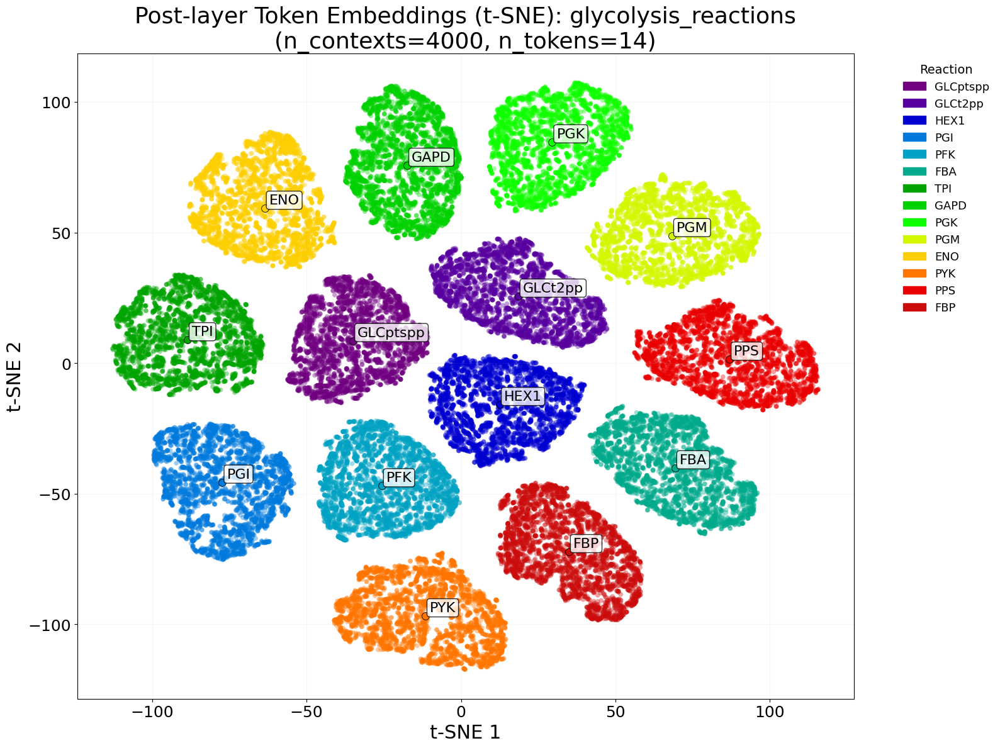

In [12]:
plot_reaction_subset_tsne(
    reservoir, output_names, tsne_context, glycolysis_reactions,
    subset_name="glycolysis_reactions", **TSNE_SETTINGS,
    sample_color_mode="reaction", show_pre_embeddings=False,
    save_path=str(pic_dir / f"{model_name}_tsne_glycolysis_reaction.png"),
)


Plot saved to c:\Users\truok\projects\metabolic-NN\pics\E_1M_d256_h8_l4_ff1024\E_evaluation\20261001T052716734294Z\figures\E_1M_d256_h8_l4_ff1024_tsne_glycolysis_rainbow.png


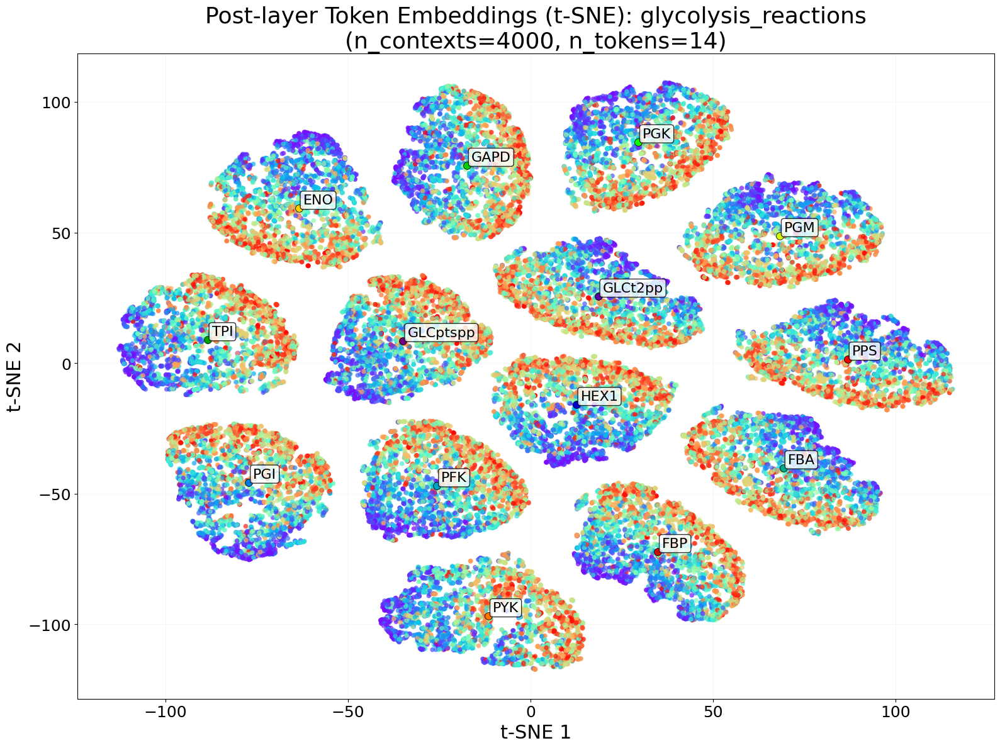

In [13]:
plot_reaction_subset_tsne(
    reservoir, output_names, tsne_context, glycolysis_reactions,
    subset_name="glycolysis_reactions", **TSNE_SETTINGS,
    sample_color_mode="rainbow", show_pre_embeddings=False,
    save_path=str(pic_dir / f"{model_name}_tsne_glycolysis_rainbow.png"),
)


### E fructose and oxygen sweep t-SNE

Use the 100 x 100 fructose/oxygen grid and the same post-layer reaction-token t-SNE and plot styles as the AMN notebook. The 38 AMN sweep inputs are checked against the saved grid. E's AMN evaluation medium sets its fixed basal inputs, including cobalamin, to 50; glycerol and the four amino acids remain 2.2, and other E-only inputs are zero. The grid coordinates and sample order are unchanged. Each selected reaction set gets one t-SNE fit, a side-by-side fructose/oxygen plot, then a four-color joint plot. Edit `pathway_reaction_lists` and `SWEEP_TSNE_REACTION_SETS` below to choose reactions. These plots are qualitative.


In [14]:
from generate_AMN_sweep import (
    BASE_EXCHANGES as AMN_SWEEP_BASE_EXCHANGES,
    FIXED_CARBON_EXCHANGES as AMN_SWEEP_FIXED_CARBON_EXCHANGES,
    AMINO_EXCHANGES as AMN_SWEEP_AMINO_EXCHANGES,
    CARBON_EXCHANGES as AMN_SWEEP_CARBON_EXCHANGES,
)

SWEEP_DATA_PATH = ROOT / "data/iML1515_AMN_sweep_10000_samples.csv"
SWEEP_METADATA_PATH = ROOT / "data/iML1515_AMN_sweep_10000_metadata.csv"
ppp_reactions = ["G6PDH2r", "PGL", "GND", "RPI", "RPE", "TKT1", "TALA", "TKT2"]
pathway_reaction_lists["ppp_reactions"] = ppp_reactions

def _reaction_token_name(reaction_id, token_names):
    base_id = str(reaction_id).removesuffix("_flux")
    candidates = (str(reaction_id), f"{base_id}_flux", base_id)
    return next((name for name in candidates if name in token_names), None)

SWEEP_TSNE_REACTION_SETS = ["glycolysis_reactions", "ppp_reactions"]
SWEEP_TSNE_SETTINGS = dict(perplexity=40.0, random_state=10, batch_size=128,
                           annotate=True, annotate_fontsize=16)

if not SWEEP_TSNE_REACTION_SETS or len(set(SWEEP_TSNE_REACTION_SETS)) != len(SWEEP_TSNE_REACTION_SETS):
    raise ValueError("Choose one or more unique sweep reaction sets")
for subset_name in SWEEP_TSNE_REACTION_SETS:
    if subset_name not in pathway_reaction_lists or not pathway_reaction_lists[subset_name]:
        raise ValueError(f"Define a nonempty pathway_reaction_lists[{subset_name!r}]")

sweep_inputs = (AMN_SWEEP_BASE_EXCHANGES + AMN_SWEEP_FIXED_CARBON_EXCHANGES
                + AMN_SWEEP_AMINO_EXCHANGES + AMN_SWEEP_CARBON_EXCHANGES)
if len(sweep_inputs) != 38 or not set(sweep_inputs) <= set(input_names):
    raise ValueError("E checkpoint must contain all 38 AMN sweep nutrient inputs")
sweep_header = pd.read_csv(SWEEP_DATA_PATH, nrows=0).columns.tolist()
if sweep_header != sweep_inputs + output_names:
    raise ValueError("AMN sweep input/output columns or order differ from the E checkpoint")
sweep_frame = pd.read_csv(SWEEP_DATA_PATH, usecols=sweep_inputs, dtype=np.float32)
sweep_frame = sweep_frame[sweep_inputs]
sweep_metadata = pd.read_csv(SWEEP_METADATA_PATH)
ev.finite_frame(sweep_frame, "AMN sweep inputs")
ev.finite_frame(sweep_metadata, "AMN sweep metadata")
required_metadata = ["sample_id", "sweep_fructose_rate", "sweep_oxygen_rate",
                     "sweep_fructose_index", "sweep_oxygen_index"]
if not set(required_metadata) <= set(sweep_metadata) or len(sweep_frame) != 10000 or len(sweep_metadata) != 10000:
    raise ValueError("Expected 10,000 sweep rows and the five grid metadata columns")
if not np.array_equal(sweep_metadata["sample_id"], np.arange(10000)):
    raise ValueError("Sweep metadata sample IDs must match CSV row order")
fructose_indices = np.repeat(np.arange(100), 100)
oxygen_indices = np.tile(np.arange(100), 100)
if not np.array_equal(sweep_metadata["sweep_fructose_index"], fructose_indices):
    raise ValueError("Fructose indices do not match the grid order")
if not np.array_equal(sweep_metadata["sweep_oxygen_index"], oxygen_indices):
    raise ValueError("Oxygen indices do not match the grid order")
for nutrient, exchange, limits, indices in (
    ("fructose", "EX_fru_e", (0.05, 2.2), fructose_indices),
    ("oxygen", "EX_o2_e", (1.0, 10.0), oxygen_indices),
):
    values = sweep_metadata[f"sweep_{nutrient}_rate"].to_numpy(float)
    levels = np.linspace(*limits, 100)
    if not np.allclose(values, levels[indices], rtol=1e-6, atol=1e-7):
        raise ValueError(f"Incorrect {nutrient} sweep values/order")
    if not np.allclose(sweep_frame[exchange], values, rtol=1e-6, atol=1e-7):
        raise ValueError(f"{nutrient} metadata and saved nutrient bounds differ")
if sweep_metadata.duplicated(["sweep_fructose_rate", "sweep_oxygen_rate"]).any():
    raise ValueError("Duplicate fructose/oxygen grid conditions")
for exchange in sweep_inputs:
    if exchange in ("EX_fru_e", "EX_o2_e"):
        continue
    expected = (10.0 if exchange in AMN_SWEEP_BASE_EXCHANGES else
                2.2 if exchange in AMN_SWEEP_FIXED_CARBON_EXCHANGES + AMN_SWEEP_AMINO_EXCHANGES else 0.0)
    if not np.allclose(sweep_frame[exchange], expected, rtol=0, atol=1e-6):
        raise ValueError(f"Unexpected saved AMN sweep bound for {exchange}")

# Use the same fixed medium as E's experimental AMN evaluation.
e_sweep_inputs = pd.DataFrame(np.zeros((len(sweep_frame), len(input_names)), dtype=np.float32),
                              columns=input_names)
e_sweep_inputs[sweep_inputs] = sweep_frame.to_numpy(np.float32)
e_fixed_base = ev.COMMON_BASE_EXCHANGES + ["EX_co2_e", "EX_cbl1_e"]
if not set(e_fixed_base) <= set(input_names):
    raise ValueError("E checkpoint is missing an AMN fixed basal input")
e_sweep_inputs[e_fixed_base] = 50.0
ev.finite_frame(e_sweep_inputs, "E sweep contexts")
e_sweep_context = torch.zeros((len(e_sweep_inputs), len(output_names)), dtype=torch.float32)
e_input_token_indices = [output_names.index(f"{name}_flux") for name in input_names]
if e_input_token_indices != reservoir.input_token_indices.detach().cpu().tolist():
    raise ValueError("E sweep nutrient-token mapping differs from the checkpoint")
e_sweep_context[:, e_input_token_indices] = torch.from_numpy(e_sweep_inputs.to_numpy(np.float32))
ev.save_json(run_dir / "e_fructose_oxygen_sweep_tsne_settings.json", {
    **SWEEP_TSNE_SETTINGS, "data_path": str(SWEEP_DATA_PATH),
    "metadata_path": str(SWEEP_METADATA_PATH), "sample_count": len(sweep_metadata),
    "reaction_sets": {name: pathway_reaction_lists[name] for name in SWEEP_TSNE_REACTION_SETS},
    "E_fixed_base_rate": 50.0, "E_fixed_base_inputs": e_fixed_base,
    "E_only_other_inputs": sorted(set(input_names) - set(sweep_inputs) - set(e_fixed_base)),
    "E_only_other_rate": 0.0,
})
print(f"Validated {len(sweep_metadata):,} E contexts on the AMN fructose/oxygen grid")


Validated 10,000 E contexts on the AMN fructose/oxygen grid


In [15]:
def make_bivariate_colors(
    fructose_values, oxygen_values, *, fructose_range, oxygen_range,
):
    """Bilinear RGB palette: light gray, high-F red, high-O blue, high-both yellow-green."""
    from matplotlib.colors import to_rgb

    fructose_values, oxygen_values = np.broadcast_arrays(
        np.asarray(fructose_values, dtype=float), np.asarray(oxygen_values, dtype=float),
    )
    if not np.isfinite(fructose_values).all() or not np.isfinite(oxygen_values).all():
        raise ValueError("Bivariate nutrient values must be finite")
    if not np.isfinite([*fructose_range, *oxygen_range]).all():
        raise ValueError("Bivariate ranges must be finite")
    if fructose_range[1] <= fructose_range[0] or oxygen_range[1] <= oxygen_range[0]:
        raise ValueError("Both nutrient ranges must have positive width")
    f = np.clip((fructose_values - fructose_range[0]) / (fructose_range[1] - fructose_range[0]), 0, 1)[..., None]
    o = np.clip((oxygen_values - oxygen_range[0]) / (oxygen_range[1] - oxygen_range[0]), 0, 1)[..., None]
    low_low = np.array(to_rgb("#F0F0F0"))
    high_f = np.array(to_rgb("#D73027"))
    high_o = np.array(to_rgb("#0072B2"))
    high_both = np.array(to_rgb("#A6CE39"))
    colors = (1-f)*(1-o)*low_low + f*(1-o)*high_f + (1-f)*o*high_o + f*o*high_both
    return np.clip(colors, 0, 1)

In [16]:
def plot_E_sweep_tsne(
    model, token_names, X_context, sweep_metadata, reaction_subset, *,
    pic_dir, model_name, perplexity=40.0, random_state=10, batch_size=128,
    annotate=True, annotate_fontsize=16,
):
    """Extract once, fit once, and render three views of the same geometry.

    token_id_labels indexes reaction_ids; sample_id_labels indexes the original
    metadata rows. All conditions are used in their validated generator order.
    """
    from openTSNE import TSNE as SweepTSNE

    if reaction_subset not in pathway_reaction_lists:
        raise ValueError(f"Unknown pathway {reaction_subset!r}; choose from {list(pathway_reaction_lists)}")
    selected_names = [_reaction_token_name(r, token_names)
                      for r in pathway_reaction_lists[reaction_subset]]
    if not selected_names or any(name is None for name in selected_names):
        raise ValueError(f"Unresolved reaction tokens for {reaction_subset}")
    selected_names = list(dict.fromkeys(selected_names))
    reaction_ids = [name[:-5] if name.endswith("_flux") else name for name in selected_names]
    token_indices = [token_names.index(name) for name in selected_names]
    n, n_tok = len(X_context), len(token_indices)
    if tuple(X_context.shape) != (n, int(model.vocab_size)) or len(token_names) != int(model.vocab_size):
        raise ValueError("Sweep contexts/token names do not match model vocabulary")
    if len(sweep_metadata) != n or not np.array_equal(sweep_metadata["sample_id"], np.arange(n)):
        raise ValueError("Sweep contexts require metadata in original sample_id order")
    if batch_size < 1 or perplexity <= 0 or 3 * perplexity > n * n_tok - 1:
        raise ValueError("Require positive batch size/perplexity and at least 3*perplexity+1 points")
    model_device = next(model.parameters()).device
    token_indices_tensor = torch.tensor(token_indices, dtype=torch.long, device=model_device)
    all_embeddings = []
    was_training = model.training
    model.eval()
    try:
        with torch.no_grad():
            for start in range(0, n, batch_size):
                batch_context = X_context[start:start + batch_size].to(model_device).unsqueeze(-1)
                embeddings, selected_indices = model(
                    batch_context, output_subset=token_indices_tensor, return_embedding=True,
                )
                # The forward returns sorted pathway + input tokens, not pathway order.
                selected_list = selected_indices.detach().cpu().tolist()
                if not set(token_indices).issubset(selected_list):
                    raise RuntimeError("Model did not return every requested pathway token")
                positions = torch.tensor([selected_list.index(idx) for idx in token_indices],
                                         dtype=torch.long, device=model_device)
                all_embeddings.append(embeddings.index_select(1, positions).detach().cpu())
    finally:
        model.train(was_training)
    embeddings_by_sample = torch.cat(all_embeddings, dim=0)
    if tuple(embeddings_by_sample.shape[:2]) != (n, n_tok):
        raise RuntimeError("Unexpected sample/reaction embedding axes")
    embeddings_flat = embeddings_by_sample.reshape(n * n_tok, -1).numpy()
    if not np.isfinite(embeddings_flat).all():
        raise ValueError("Nonfinite post-layer embeddings")
    token_id_labels = np.tile(np.arange(n_tok, dtype=np.int64), n)
    sample_id_labels = np.repeat(sweep_metadata["sample_id"].to_numpy(dtype=np.int64), n_tok)
    print(f"Sweep t-SNE: {n:,} contexts × {n_tok} reactions = {len(embeddings_flat):,} points")
    # One seeded fit only. FFT avoids Barnes-Hut repulsion costs at 140k points.
    embedding_2d = np.asarray(SweepTSNE(
        n_components=2, perplexity=perplexity, initialization="pca",
        random_state=random_state, negative_gradient_method="fft", n_jobs=1,
    ).fit(embeddings_flat)).copy()
    if embedding_2d.shape != (n * n_tok, 2) or not np.isfinite(embedding_2d).all():
        raise ValueError("Invalid t-SNE coordinates")
    reaction_centers = np.array([np.median(embedding_2d[token_id_labels == i], axis=0)
                                 for i in range(n_tok)])
    fructose_point_values = sweep_metadata["sweep_fructose_rate"].to_numpy()[sample_id_labels]
    oxygen_point_values = sweep_metadata["sweep_oxygen_rate"].to_numpy()[sample_id_labels]
    fructose_range = (float(fructose_point_values.min()), float(fructose_point_values.max()))
    oxygen_range = (float(oxygen_point_values.min()), float(oxygen_point_values.max()))
    bivariate_colors = make_bivariate_colors(
        fructose_point_values, oxygen_point_values, fructose_range=fructose_range, oxygen_range=oxygen_range,
    )
    reaction_colors = plt.cm.nipy_spectral(np.linspace(0.05, 0.95, n_tok))
    point_size = 4.0
    center_size = 86.0 if n_tok <= 10 else 72.0 if n_tok <= 20 else 36.0
    lower, upper = embedding_2d.min(axis=0), embedding_2d.max(axis=0)
    margin = np.maximum(upper - lower, 1e-6) * 0.05
    xlim = (lower[0] - margin[0], upper[0] + margin[0])
    ylim = (lower[1] - margin[1], upper[1] + margin[1])

    def style_sweep_axis(ax, neutral_centers=False):
        for i, center in enumerate(reaction_centers):
            ax.scatter(*center, s=center_size, marker="o",
                       color="white" if neutral_centers else reaction_colors[i],
                       edgecolor="black", linewidth=0.6, zorder=3)
            if annotate:
                ax.annotate(reaction_ids[i], center, xytext=(5, 5), textcoords="offset points",
                            fontsize=annotate_fontsize,
                            bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.8))
        ax.set(xlim=xlim, ylim=ylim)
        ax.set_xlabel("t-SNE 1", fontsize=22)
        ax.set_ylabel("t-SNE 2", fontsize=22)
        ax.tick_params(labelsize=18)
        ax.grid(alpha=0.1)

    pathway_title = reaction_subset.removesuffix("_reactions").replace("_", " ")
    title = f"E fructose/oxygen sweep: {pathway_title} reaction embeddings"
    unit = r"(mmol gDW$^{-1}$ h$^{-1}$)"
    os.makedirs(pic_dir, exist_ok=True)
    filename_base = os.path.join(str(pic_dir), f"{model_name}_tsne_fructose_oxygen_sweep_{reaction_subset}")
    fig, axes = plt.subplots(1, 2, figsize=(24, 10))
    for ax, values, cmap, limits, nutrient in zip(
        axes, [fructose_point_values, oxygen_point_values], ["viridis", "plasma"],
        [fructose_range, oxygen_range], ["Fructose", "Oxygen"],
    ):
        cloud = ax.scatter(embedding_2d[:, 0], embedding_2d[:, 1], c=values,
                           cmap=cmap, vmin=limits[0], vmax=limits[1], s=point_size,
                           alpha=0.70, edgecolors="none")
        style_sweep_axis(ax)
        ax.set_title(f"{nutrient} uptake", fontsize=26)
        colorbar = fig.colorbar(cloud, ax=ax, fraction=0.046, pad=0.04)
        colorbar.set_label(f"{nutrient} uptake bound {unit}", fontsize=18)
        colorbar.ax.tick_params(labelsize=16)
    fig.suptitle(title, fontsize=26)
    fig.tight_layout()
    single_path = filename_base + "_single_variables.png"
    fig.savefig(single_path, bbox_inches="tight", dpi=300)
    plt.show()
    plt.close(fig)

    fig = plt.figure(figsize=(16, 12))
    layout = fig.add_gridspec(1, 2, width_ratios=[3.4, 1.2])
    ax, key_ax = fig.add_subplot(layout[0, 0]), fig.add_subplot(layout[0, 1])
    ax.scatter(embedding_2d[:, 0], embedding_2d[:, 1], c=bivariate_colors,
               s=point_size, alpha=0.90, edgecolors="none")
    style_sweep_axis(ax, neutral_centers=True)
    legend_f, legend_o = np.meshgrid(np.linspace(*fructose_range, 100), np.linspace(*oxygen_range, 100))
    legend_colors = make_bivariate_colors(
        legend_f, legend_o, fructose_range=fructose_range, oxygen_range=oxygen_range,
    )
    key_ax.imshow(legend_colors, origin="lower", extent=[*fructose_range, *oxygen_range], aspect="auto")
    key_ax.set_box_aspect(1)
    key_ax.set_xticks(fructose_range)
    key_ax.set_yticks(oxygen_range)
    key_ax.set_xlabel(f"Fructose\n{unit}", fontsize=17)
    key_ax.set_ylabel(f"Oxygen\n{unit}", fontsize=17)
    key_ax.tick_params(labelsize=16)
    key_ax.set_title("Joint nutrient bounds", fontsize=19)
    fig.suptitle(title, fontsize=26)
    fig.tight_layout()
    bivariate_path = filename_base + "_bivariate.png"
    fig.savefig(bivariate_path, bbox_inches="tight", dpi=300)
    plt.show()
    plt.close(fig)
    print(f"Saved: {single_path}\nSaved: {bivariate_path}")
    return dict(
        embedding_2d=embedding_2d, token_id_labels=token_id_labels,
        sample_id_labels=sample_id_labels, reaction_ids=reaction_ids,
        fructose_point_values=fructose_point_values, oxygen_point_values=oxygen_point_values,
        reaction_centers=reaction_centers, bivariate_colors=bivariate_colors,
        single_variables_path=single_path, bivariate_path=bivariate_path,
    )

Sweep t-SNE: 10,000 contexts × 14 reactions = 140,000 points


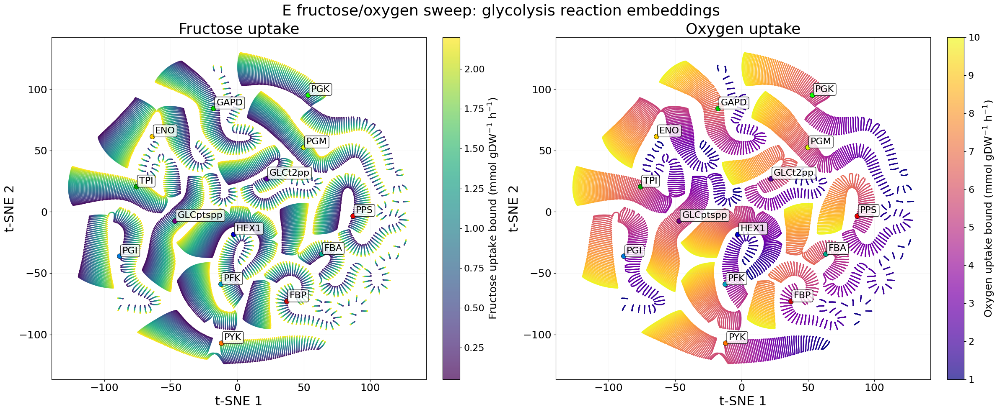

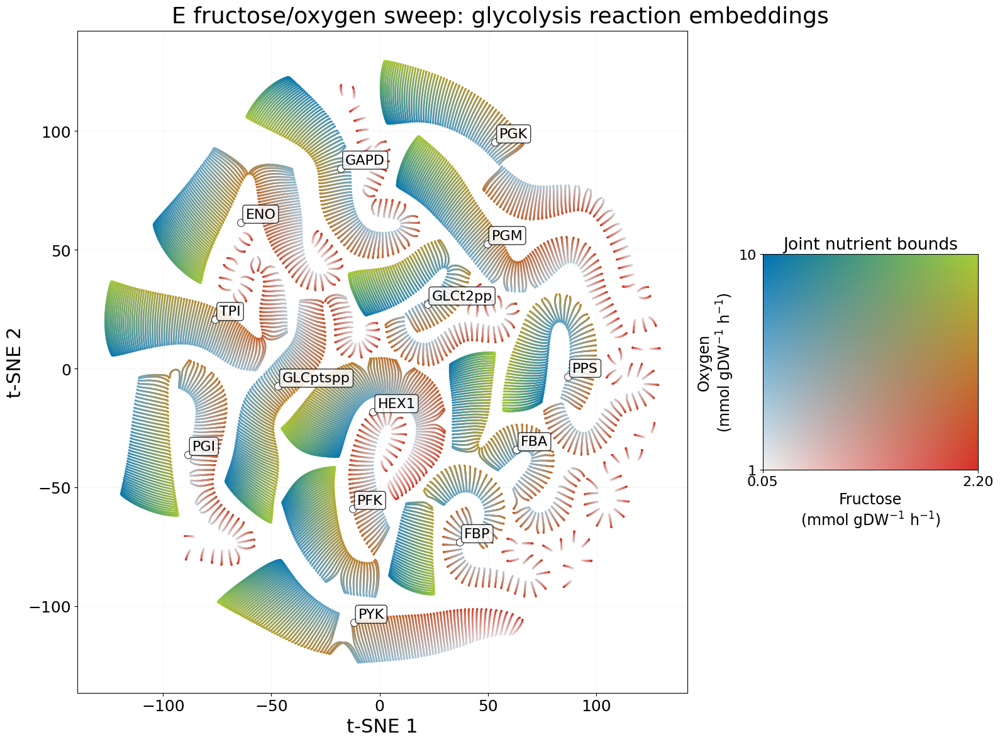

Saved: c:\Users\truok\projects\metabolic-NN\pics\E_1M_d256_h8_l4_ff1024\E_evaluation\20261001T052716734294Z\figures\E_1M_d256_h8_l4_ff1024_tsne_fructose_oxygen_sweep_glycolysis_reactions_single_variables.png
Saved: c:\Users\truok\projects\metabolic-NN\pics\E_1M_d256_h8_l4_ff1024\E_evaluation\20261001T052716734294Z\figures\E_1M_d256_h8_l4_ff1024_tsne_fructose_oxygen_sweep_glycolysis_reactions_bivariate.png
Sweep t-SNE: 10,000 contexts × 8 reactions = 80,000 points


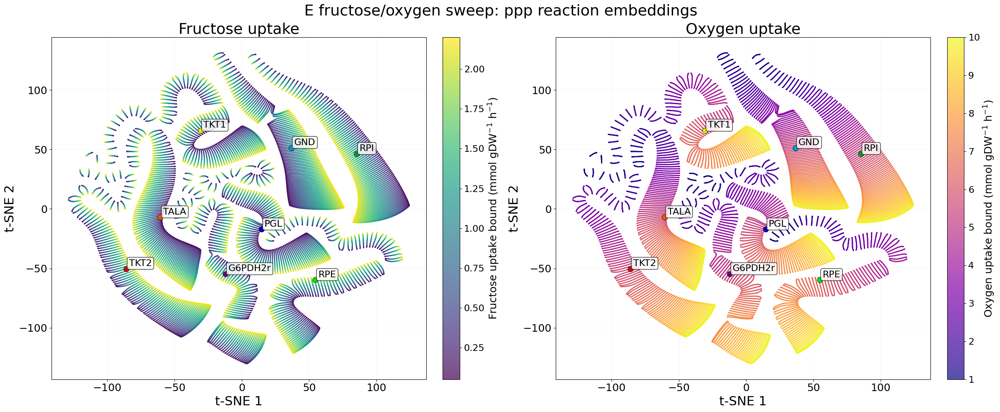

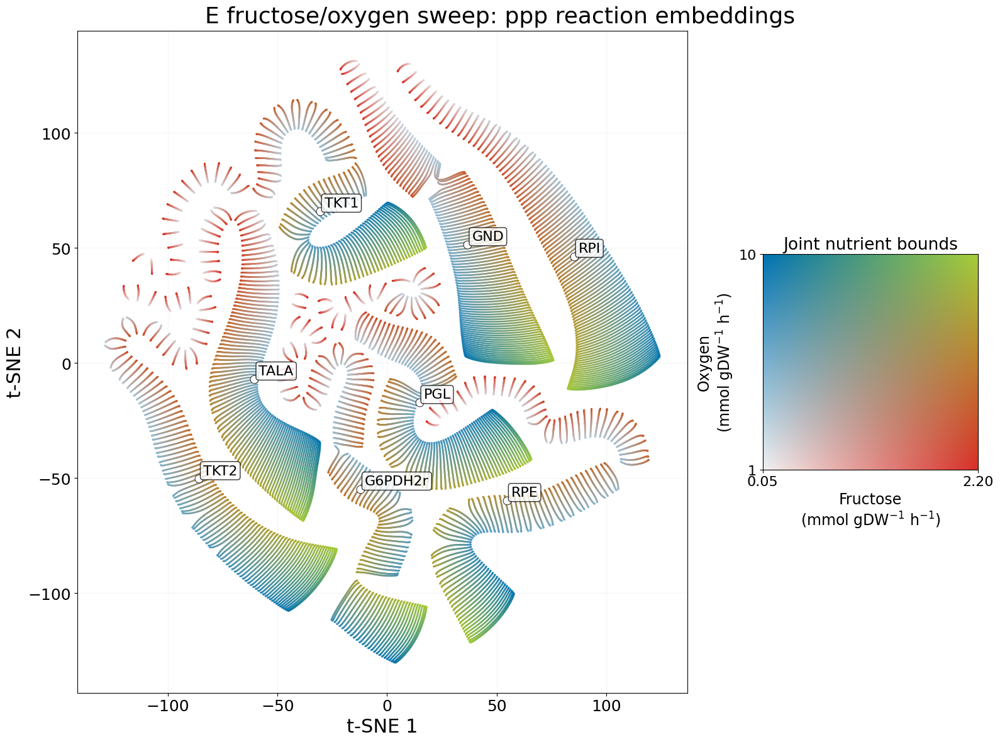

Saved: c:\Users\truok\projects\metabolic-NN\pics\E_1M_d256_h8_l4_ff1024\E_evaluation\20261001T052716734294Z\figures\E_1M_d256_h8_l4_ff1024_tsne_fructose_oxygen_sweep_ppp_reactions_single_variables.png
Saved: c:\Users\truok\projects\metabolic-NN\pics\E_1M_d256_h8_l4_ff1024\E_evaluation\20261001T052716734294Z\figures\E_1M_d256_h8_l4_ff1024_tsne_fructose_oxygen_sweep_ppp_reactions_bivariate.png


In [17]:
sweep_tsne_results = {}
for reaction_subset in SWEEP_TSNE_REACTION_SETS:
    sweep_tsne_results[reaction_subset] = plot_E_sweep_tsne(
        reservoir, output_names, e_sweep_context, sweep_metadata,
        reaction_subset=reaction_subset, pic_dir=pic_dir, model_name=model_name,
        **SWEEP_TSNE_SETTINGS,
    )


## Independent simulated-data fidelity

A and B are scored separately, plus an equally weighted pooled score. Full-output inference is mandatory. The helper streams all rows, exports per-flux error/activity and per-row mass-balance/bound diagnostics, and checks objective agreement on the configured subset. A's CO2/acetate uptake semantics and B's secretion-cap semantics remain distinct. The generation commands are part of the recorded provenance.

In [18]:
if RUN_SIMULATED:
    for spec in SIMULATED.values():
        training_path = Path(str(training_info.get("dataset", "")))
        if Path(spec["path"]).resolve() == training_path.resolve():
            raise ValueError("Simulated evaluation path points at the training dataset.")
    simulated_summary = ev.simulated_fidelity(reservoir, input_names, output_names,
        SIMULATED, XML_PATH, run_dir / "simulated", batch_size=SIM_BATCH_SIZE,
        objective_samples=OBJECTIVE_CHECK_SAMPLES, fraction=0.999)
    display(simulated_summary)
else:
    print("Optional full A/B fidelity analysis skipped.")


Optional full A/B fidelity analysis skipped.


## AMN: prepare model E media

For the 110 experimental AMN media, E's evaluation mapping sets basal inputs (including CO2) and cobalamin to 50, fixed glycerol/amino acids to 2.2, and absent glucose/ethanol to zero. Other E input channels are zero for this task. E was trained with general media sampling; these are the experimental AMN evaluation settings. The configured E checkpoint has 55 inputs. A masked sigmoid prior predicts the ten carbon rates and oxygen in checkpoint input order. Carbon rates range from 0 to 2.2; oxygen from 0 to 10. These ranges retain the existing prior parameterization, including values below the simulation's sampling minima. Experimental SD is joined by medium composition and checked against measured growth.


In [19]:
if RUN_AMN:
    amn_data = ev.load_amn(AMN_DIR, input_names=input_names, model_family=MODEL_FAMILY,
                           feature_order="checkpoint")
    display(pd.DataFrame({"input": list(amn_data["fixed"]), "fixed_value": list(amn_data["fixed"].values())}))
    print("AMN features:", amn_data["features"])
    print("AMN shape:", amn_data["X"].shape)
    ev.save_json(run_dir / "amn_schema.json", {"features": amn_data["features"],
        "targets": amn_data["targets"], "sample_ids": amn_data["ids"].tolist(), "fixed": amn_data["fixed"]})


,input,fixed_value
0,EX_glc__D_e,0.0
1,EX_o2_e,0.0
2,EX_co2_e,50.0
3,EX_etoh_e,0.0
4,EX_ac_e,0.0
5,EX_pi_e,50.0
6,EX_fe3_e,50.0
7,EX_h_e,50.0
8,EX_mn2_e,50.0
9,EX_fe2_e,50.0


AMN features: ['EX_o2_e', 'EX_ac_e', 'EX_gal_e', 'EX_fru_e', 'EX_malt_e', 'EX_tre_e', 'EX_melib_e', 'EX_rib__D_e', 'EX_lac__D_e', 'EX_pyr_e', 'EX_succ_e']
AMN shape: (110, 11)


### Train the AMN MLP with the original repeated-CV protocol

Match `ecoli_iML1515_AMN_MINN_model_testing_trial.ipynb`: ten folds stratified by carbon count, repeated with seeds 10/11/12; training seed 10 for every fold. Train on 99 media and select the best checkpoint using the 11 held-out media (100 epochs maximum, patience 15), then score that checkpoint without refitting. Preserve checkpoint-order features, AdamW, Huber delta 0.03, no gradient clipping, training batch 1 and validation batch 2. This reproduces the historical protocol; held-out targets participate in epoch selection. Rerun this notebook to obtain model E results.

In [20]:
if RUN_AMN:
    amn_result = ev.run_amn(reservoir, output_names, amn_data, AMN_SETTINGS, run_dir / "amn")
    display(amn_result["summary"])
    display(amn_result["summary"].drop(columns="repeat").agg(["mean", lambda x: x.std(ddof=0)]))


AMN repeat 10, fold 1: legacy_outer_early_stopping, selected epoch 11
AMN repeat 10, fold 2: legacy_outer_early_stopping, selected epoch 12
AMN repeat 10, fold 3: legacy_outer_early_stopping, selected epoch 17
AMN repeat 10, fold 4: legacy_outer_early_stopping, selected epoch 48
AMN repeat 10, fold 5: legacy_outer_early_stopping, selected epoch 6
AMN repeat 10, fold 6: legacy_outer_early_stopping, selected epoch 4
AMN repeat 10, fold 7: legacy_outer_early_stopping, selected epoch 1
AMN repeat 10, fold 8: legacy_outer_early_stopping, selected epoch 27
AMN repeat 10, fold 9: legacy_outer_early_stopping, selected epoch 44
AMN repeat 10, fold 10: legacy_outer_early_stopping, selected epoch 7
AMN repeat 11, fold 1: legacy_outer_early_stopping, selected epoch 8
AMN repeat 11, fold 2: legacy_outer_early_stopping, selected epoch 21
AMN repeat 11, fold 3: legacy_outer_early_stopping, selected epoch 23
AMN repeat 11, fold 4: legacy_outer_early_stopping, selected epoch 9
AMN repeat 11, fold 5: le

,repeat,R2,Pearson_r2,MAE,RMSE,NE
0,10,0.849171,0.849490,0.024831,0.032749,0.132127
1,11,0.833435,0.834493,0.025712,0.034415,0.138849
2,12,0.847982,0.848131,0.025330,0.032878,0.132647


,R2,Pearson_r2,MAE,RMSE,NE
mean,0.843529,0.844038,0.025291,0.033347,0.134541
<lambda>,0.007154,0.006772,0.000361,0.000757,0.003053


### AMN growth errors and uncertainty

Repeated-CV reporting: average OOF predictions per medium, then compute R2, MAE and RMSE across those means. Report population SD of per-repeat metrics separately. Orange horizontal bars show experimental SD; orange vertical bars show prediction SD across repeats (ddof=1). This spread is not a calibrated prediction interval.


,Metric,OOF score,SD across repeats
0,R2,0.861890,0.007154
1,MAE,0.023926,0.000361
2,RMSE,0.031338,0.000757


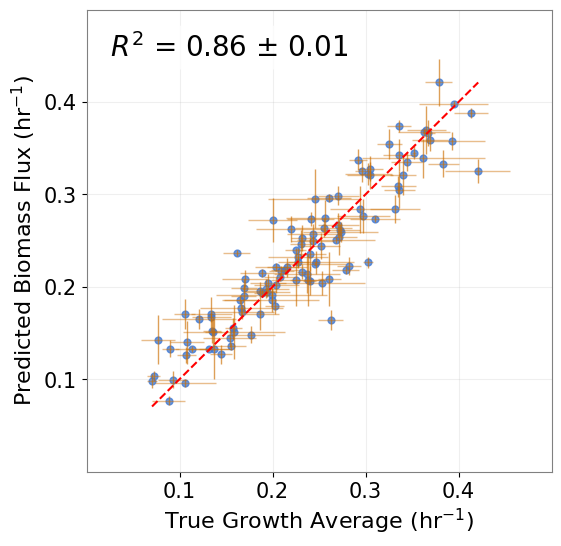

,repeat,carbon_count,R2,Pearson_r2,MAE,RMSE,NE
0,10,1,0.642775,0.799693,0.022325,0.028730,0.202093
1,10,2,0.798401,0.804431,0.025952,0.032560,0.151800
2,10,3,0.769425,0.778842,0.023125,0.033772,0.142455
3,10,4,0.826636,0.829279,0.026602,0.032748,0.112531
4,11,1,0.459632,0.670427,0.025704,0.035336,0.248557
5,11,2,0.812732,0.826291,0.027659,0.031381,0.146305
6,11,3,0.781576,0.783900,0.023555,0.032870,0.138651
7,11,4,0.778188,0.784742,0.026897,0.037042,0.127287
8,12,1,0.599954,0.687443,0.026603,0.030404,0.213863
9,12,2,0.814682,0.818713,0.024965,0.031218,0.145542


In [21]:
# Refresh an older kernel import without discarding trained results.
if not hasattr(ev, "summarize_amn_oof"):
    from importlib import reload
    ev = reload(ev)

if amn_result is not None:
    oof = amn_result["oof"]
    means, amn_scores, amn_spread = ev.summarize_amn_oof(
        oof, len(amn_data["ids"]), AMN_SETTINGS["split_seeds"])
    oof_true_cv = means.truth.to_numpy()
    oof_pred_cv = means.prediction.to_numpy()
    oof_std_cv = amn_data["growth_std"][means.index]
    oof_pred_seed_std_cv = means.prediction_std.to_numpy()
    r2_oof, r2_oof_std = amn_scores["R2"], amn_spread["R2"]
    line_min_cv = float(max(0.0, min(oof_true_cv.min(), oof_pred_cv.min())))
    line_max_cv = float(min(0.5, max(oof_true_cv.max(), oof_pred_cv.max())))

    def format_r2_with_std(r2_value, r2_std):
        std_precision = 3 if abs(float(r2_std)) < 0.005 else 2
        return f"$R^2$ = {r2_value:.2f} $\\pm$ {r2_std:.{std_precision}f}"

    amn_metric_summary = pd.DataFrame([
        {"Metric": key, "OOF score": amn_scores[key], "SD across repeats": amn_spread[key]}
        for key in ("R2", "MAE", "RMSE")])
    display(amn_metric_summary)
    amn_metric_summary.to_csv(run_dir / "amn/aggregated_oof_metrics.csv", index=False)

    plt.figure(figsize=(6, 6))
    plt.hlines(
        y=oof_pred_cv,
        xmin=oof_true_cv - oof_std_cv,
        xmax=oof_true_cv + oof_std_cv,
        colors="#CC6E00",
        alpha=0.45,
        linewidth=1.0,
    )
    plt.vlines(
        x=oof_true_cv,
        ymin=oof_pred_cv - oof_pred_seed_std_cv,
        ymax=oof_pred_cv + oof_pred_seed_std_cv,
        colors="#CC6E00",
        alpha=0.65,
        linewidth=1.0,
    )
    plt.scatter(oof_true_cv, oof_pred_cv, alpha=0.78, s=24, c="#3F7BD9")
    plt.plot([line_min_cv, line_max_cv], [line_min_cv, line_max_cv], "r--", lw=1.5)
    plt.xlabel(r"True Growth Average (hr$^{-1}$)", fontsize=16)
    plt.ylabel(r"Predicted Biomass Flux (hr$^{-1}$)", fontsize=16)
    #plt.title("Out-of-Fold True vs Predicted", fontsize=16)
    plt.xlim(0.0, 0.5)
    plt.ylim(0.0, 0.5)
    plt.text(0.05, 0.95, format_r2_with_std(r2_oof, r2_oof_std), transform=plt.gca().transAxes,
             ha="left", va="top", fontsize=20,
             bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.75))
    plt.xticks(np.arange(0.1, 0.5, 0.1), fontsize=15)
    plt.yticks(np.arange(0.1, 0.5, 0.1), fontsize=15)
    ax = plt.gca()
    for spine in ax.spines.values():
        spine.set_color("gray")
    plt.grid(alpha=0.2)
    plt.savefig(pic_dir / f"{model_name}_amn_growth.png", dpi=300, bbox_inches="tight")
    plt.show()
    carbon_metrics = pd.DataFrame([{"repeat": repeat, "carbon_count": count, **ev.metrics(part.truth, part.prediction)}
        for (repeat, count), part in oof.groupby(["repeat", "carbon_count"])])
    carbon_metrics.to_csv(run_dir / "amn/carbon_count_metrics.csv", index=False)
    display(carbon_metrics)
    means.to_csv(run_dir / "amn/mean_predictions.csv")


## MINN: prepare data and model E context

The primary fitted target file supplies both flux targets and observed glucose/oxygen feature values, preserving the maintained Table 4 workflow. The loader checks experiment IDs across all three files. The front MLP receives 141 features; 42 signed non-context targets train its latent controls. All 47 source fluxes are retained for downstream pFBA evaluation. For experimental MINN evaluation, basal inputs, including cobalamin, are 50. Other carbon and amino-acid inputs are zero. Cobalamin is a declared input of the configured 55-input E checkpoint.

Scaling is fitted inside each training fold. Observed glucose/oxygen are passed separately in physical units, so scaling cannot change copied reservoir bounds. Neither mode trains against exact context targets.

In [22]:
if RUN_MINN:
    for target_mode in TARGET_MODES:
        data = ev.load_minn(MINN_DIR, output_names, target_mode,
                            input_names=input_names, model_family=MODEL_FAMILY,
                            legacy_protocol=MINN_SETTINGS["legacy_protocol"])
        minn_data[target_mode] = data
        print(target_mode, "features/targets:", data["X"].shape, data["y"].shape)
        mapping = pd.DataFrame(data["mapping"], columns=["source", "token", "sign"])
        display(mapping)
        mapping.to_csv(run_dir / f"{target_mode}_mapping.csv", index=False)
        ev.save_json(run_dir / f"{target_mode}_schema.json", {"features": data["features"],
            "targets": data["targets"], "samples": data["ids"].tolist(), "fixed": data["fixed"]})


minn_fitted features/targets: (29, 141) (29, 42)


,source,token,sign
0,R_GLCptspp,GLCptspp_flux,1.0
1,R_PGI_fwd,PGI_flux,1.0
2,R_PFK,PFK_flux,1.0
3,R_FBA_fwd,FBA_flux,1.0
4,R_TPI_fwd,TPI_flux,1.0
5,R_PGK_rev,PGK_flux,-1.0
6,R_GAPD_fwd,GAPD_flux,1.0
7,R_ENO_fwd,ENO_flux,1.0
8,R_PGM_rev,PGM_flux,-1.0
9,R_PYK,PYK_flux,1.0


### Train MINN MLP: measured glucose/oxygen context

Use the original MINN protocol: tune once with five-fold CV over the full MINN dataset (50 trials), then reuse the selected parameters for every leave-one-out fit. Each fit uses its held-out condition for early stopping and restores the best weights. This MLP predicts CO2, ethanol and acetate; observed glucose/O2 are copied into reservoir inputs.

Full-dataset HPO and held-out-condition epoch selection follow the original protocol. Reproduction uses CUDA AMP, batch 2 on CUDA or 5 on CPU, and the original dropout and validation-loader RNG consumption. Seed once before the measured study, then run predicted mode without reseeding. These scores include held-out-condition epoch selection.


In [23]:
if RUN_MINN:
    # Seed once, then preserve RNG state through HPO, LOO and the predicted-mode study.
    ev.seed_all(MINN_SETTINGS["seed"])
    for target_mode, data in minn_data.items():
        minn_results[(target_mode, "measured")] = ev.run_minn(reservoir, output_names, data,
            "measured", MINN_SETTINGS, run_dir / "minn" / target_mode / "measured")


c:\Users\truok\projects\metabolic-NN\venv\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
c:\Users\truok\projects\metabolic-NN\venv\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  optuna_warn(
[I 2026-10-01 12:07:36,154] A new study created in memory with name: no-name-a25b8538-aae7-4825-be33-13242a89b5a2
[I 2026-10-01 12:16:17,418] Trial 0 finished with value: 0.4796426601089572 and parameters: {'drop_rate': 0.4, 'learning_rate': 0.003538123595632612, 'weight_decay': 5.5530705063765935e-05}. Best is trial 0 with value: 0.4796426601089572.
[I 2026-10-01 12:22:07,349] Trial 1 finished with value: 0.4772116916267741 and parameters: {'drop_rate': 0.1, 'learning_rate': 0.005656664562602267, 'weight_decay': 0.00022955120063380515}. Best is trial 1 with value:

MINN measured global best parameters: {'drop_rate': 0.2, 'learning_rate': 0.0050028787020333304, 'weight_decay': 0.00043737378150523814}
MINN measured: 1/29, best epoch 20
MINN measured: 2/29, best epoch 37
MINN measured: 3/29, best epoch 20
MINN measured: 4/29, best epoch 13
MINN measured: 5/29, best epoch 16
MINN measured: 6/29, best epoch 15
MINN measured: 7/29, best epoch 3
MINN measured: 8/29, best epoch 2
MINN measured: 9/29, best epoch 1
MINN measured: 10/29, best epoch 18
MINN measured: 11/29, best epoch 20
MINN measured: 12/29, best epoch 10
MINN measured: 13/29, best epoch 16
MINN measured: 14/29, best epoch 17
MINN measured: 15/29, best epoch 11
MINN measured: 16/29, best epoch 21
MINN measured: 17/29, best epoch 14
MINN measured: 18/29, best epoch 1
MINN measured: 19/29, best epoch 18
MINN measured: 20/29, best epoch 28
MINN measured: 21/29, best epoch 12
MINN measured: 22/29, best epoch 1
MINN measured: 23/29, best epoch 1
MINN measured: 24/29, best epoch 5
MINN measured: 

### Train a separate MINN MLP: predicted glucose/oxygen context

This mode independently predicts all five latent context values. It receives the same feature matrix and tuning budget as the measured mode. Observed glucose/O2 remain available as features and remain the downstream pFBA uptake bounds. Run this cell after the measured study without reseeding, matching the original random-state progression. Both modes are retained.

In [24]:
if RUN_MINN:
    for target_mode, data in minn_data.items():
        minn_results[(target_mode, "predicted")] = ev.run_minn(reservoir, output_names, data,
            "predicted", MINN_SETTINGS, run_dir / "minn" / target_mode / "predicted")


c:\Users\truok\projects\metabolic-NN\venv\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
c:\Users\truok\projects\metabolic-NN\venv\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  optuna_warn(
[I 2026-10-01 16:14:50,272] A new study created in memory with name: no-name-f72b346b-97b7-4d51-b7f2-e6d94773e16d
[I 2026-10-01 16:21:41,884] Trial 0 finished with value: 0.7319845483206896 and parameters: {'drop_rate': 0.4, 'learning_rate': 0.003538123595632612, 'weight_decay': 5.5530705063765935e-05}. Best is trial 0 with value: 0.7319845483206896.
[I 2026-10-01 16:28:17,742] Trial 1 finished with value: 0.7317478155615426 and parameters: {'drop_rate': 0.1, 'learning_rate': 0.005656664562602267, 'weight_decay': 0.00022955120063380515}. Best is trial 1 with value:

MINN predicted global best parameters: {'drop_rate': 0.1, 'learning_rate': 0.008243188286147412, 'weight_decay': 7.568151559792469e-08}
MINN predicted: 1/29, best epoch 28
MINN predicted: 2/29, best epoch 12
MINN predicted: 3/29, best epoch 22
MINN predicted: 4/29, best epoch 16
MINN predicted: 5/29, best epoch 48
MINN predicted: 6/29, best epoch 55
MINN predicted: 7/29, best epoch 8
MINN predicted: 8/29, best epoch 4
MINN predicted: 9/29, best epoch 34
MINN predicted: 10/29, best epoch 46
MINN predicted: 11/29, best epoch 69
MINN predicted: 12/29, best epoch 66
MINN predicted: 13/29, best epoch 4
MINN predicted: 14/29, best epoch 26
MINN predicted: 15/29, best epoch 4
MINN predicted: 16/29, best epoch 100
MINN predicted: 17/29, best epoch 39
MINN predicted: 18/29, best epoch 4
MINN predicted: 19/29, best epoch 53
MINN predicted: 20/29, best epoch 41
MINN predicted: 21/29, best epoch 36
MINN predicted: 22/29, best epoch 3
MINN predicted: 23/29, best epoch 59
MINN predicted: 24/29, best

### Direct MINN flux and context diagnostics

Regression R? and squared Pearson correlation (`Pearson_r2`) are separate columns. The latter preserves the historical Table 4-style correlation metric. Undefined constant-target R? or zero-denominator normalized error remains undefined. Measured-copy identity values are not reported as predictions.

,target_mode,context_mode,R2,Pearson_r2,MAE,RMSE,NE
0,minn_fitted,measured,0.743965,0.748243,0.567582,1.343524,0.470764
1,minn_fitted,predicted,0.606585,0.653034,0.912549,1.665410,0.583551


minn_fitted measured


,R2,Pearson_r2,MAE,RMSE,NE
mean,0.368815,0.926267,0.567582,0.837065,0.379869
<lambda>,2.766188,0.074161,0.740931,1.050894,0.626966


,flux,R2,Pearson_r2,MAE,RMSE,NE
9,PYK_flux,-3.340719,0.311417,1.588587,1.813915,0.998520
8,PGM_flux,0.209038,0.243063,1.151747,2.467184,0.412459
6,GAPD_flux,0.213666,0.214599,1.126926,3.072173,0.433221
5,PGK_flux,0.302176,0.309016,1.104629,2.894111,0.408112
7,ENO_flux,0.182303,0.207593,1.102285,2.508532,0.419372
3,FBA_flux,-0.344418,0.017905,1.064496,1.914230,0.564836
2,PFK_flux,-0.391955,0.007433,0.994925,1.947779,0.574735
23,SUCOAS_flux,0.058970,0.185379,0.992074,1.854854,0.583858
25,SUCDi_flux,-0.019014,0.217734,0.904548,1.800913,0.525380
27,MDH_flux,0.073762,0.308661,0.881184,1.580766,0.429909


,source,role,min,max,mean,observed_mean
0,R_EX_glc__D_e_rev,copied,2.763000e+00,12.890100,3.880190,3.880190
1,R_EX_o2_e_rev,copied,6.020400e+00,26.241699,9.602583,9.602583
2,R_EX_co2_e_fwd,latent prediction,5.550818e-06,0.604062,0.123404,7.989683
3,R_EX_etoh_e,latent prediction,5.747735e-08,0.340055,0.065143,0.011659
4,R_EX_ac_e,latent prediction,2.703645e-10,2.828498,0.310049,0.083952


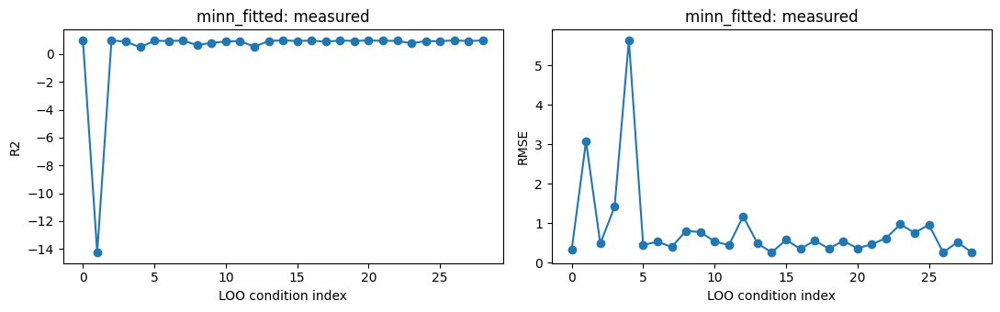

minn_fitted predicted


,R2,Pearson_r2,MAE,RMSE,NE
mean,0.658177,0.749771,0.912549,1.349619,0.519518
<lambda>,0.173359,0.070259,0.762623,0.975765,0.114809


,flux,R2,Pearson_r2,MAE,RMSE,NE
10,PDH_flux,-9.004291,0.760854,3.478854,3.662578,1.021908
19,CS_flux,-3.234687,0.599421,3.019908,3.458194,0.996897
27,MDH_flux,-3.108845,0.451725,2.824376,3.329403,0.905472
23,SUCOAS_flux,-1.763321,0.717882,2.535224,3.178511,1.000510
26,FUM_flux,-2.074884,0.506733,2.331096,3.021810,0.846073
21,ACONTa_flux,-2.942778,0.626873,1.782524,2.181052,0.756571
25,SUCDi_flux,-1.339601,0.540138,1.759210,2.728812,0.796076
9,PYK_flux,-3.308287,0.227490,1.583080,1.807126,0.994783
3,FBA_flux,-0.759177,0.899693,1.582704,2.189686,0.646115
6,GAPD_flux,0.523907,0.842671,1.500194,2.390496,0.337095


,source,role,min,max,mean,observed_mean
0,R_EX_glc__D_e_rev,latent prediction,1.831740e+00,7.933952,2.978636,3.880190
1,R_EX_o2_e_rev,latent prediction,7.476249e-13,0.000911,0.000227,9.602583
2,R_EX_co2_e_fwd,latent prediction,1.691898e-10,2.102883,0.880136,7.989683
3,R_EX_etoh_e,latent prediction,1.264512e-11,0.005316,0.001189,0.011659
4,R_EX_ac_e,latent prediction,2.828498e+00,9.882864,4.714287,0.083952


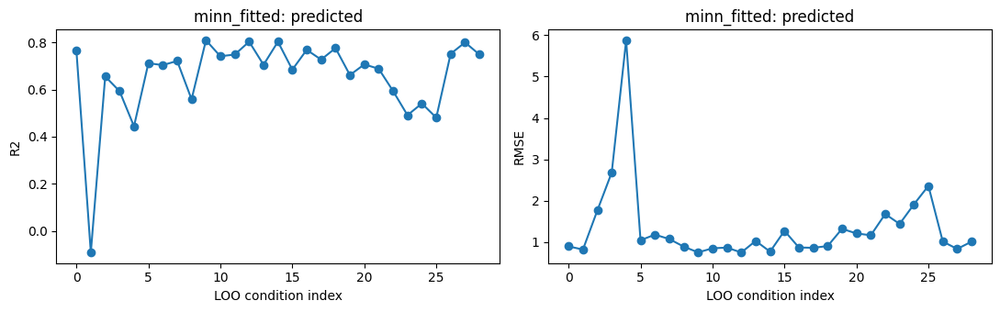

In [25]:
if RUN_MINN:
    direct_summary = pd.DataFrame([{"target_mode": target, "context_mode": mode, **result["pooled"]}
        for (target, mode), result in minn_results.items()])
    display(direct_summary)
    direct_summary.to_csv(run_dir / "minn_direct_summary.csv", index=False)
    for (target, mode), result in minn_results.items():
        print(target, mode)
        display(result["per_sample"].drop(columns="sample").agg(["mean", lambda x: x.std(ddof=0)]))
        display(result["per_flux"].sort_values("MAE", ascending=False).head(10))
        context_rows = []
        for j, source in enumerate(ev.CONTEXT_SOURCES):
            values = result["context"][:, j]
            context_rows.append({"source": source, "role": "copied" if mode == "measured" and j < 2 else "latent prediction",
                "min": values.min(), "max": values.max(), "mean": values.mean(),
                "observed_mean": minn_data[target]["context_truth"][:, j].mean()})
        display(pd.DataFrame(context_rows))
        pd.DataFrame(context_rows).to_csv(run_dir / "minn" / target / mode / "context_diagnostics.csv", index=False)
        fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
        for ax, metric in zip(axes, ["R2", "RMSE"]):
            ax.plot(result["per_sample"][metric].to_numpy(), "o-")
            ax.set(xlabel="LOO condition index", ylabel=metric, title=f"{target}: {mode}")
        fig.tight_layout()
        fig.savefig(pic_dir / f"{model_name}_{target}_{mode}_loo.png", dpi=180)
        plt.show()


## pFBA baseline and both reservoir-to-pFBA variants

All methods preserve the same iML1515 SBML background medium and core objective. Glucose/O2 are observed uptake lower-bound caps, not equality constraints. The reservoir's MINN input vector follows its pretraining base-50 contract; the downstream mechanistic baseline follows the maintained Table 4 SBML medium. The downstream pFBA fraction is 1.0, matching the original MINN protocol. OOF CO2/ethanol/acetate predictions become nonnegative secretion upper caps. Every sample retains a solver status.

In [26]:
if RUN_MINN:
    for target, data in minn_data.items():
        pfba_results[target] = {"baseline": ev.run_pfba(XML_PATH, data, fraction=PFBA_FRACTION)}
        display(pfba_results[target]["baseline"]["status"])


,sample,status,error
0,REF,optimal,
1,WT_0.1h-1,optimal,
2,WT_0.4h-1,optimal,
3,WT_0.5h-1,optimal,
4,WT_0.7h-1,optimal,
5,galM,optimal,
6,glk,optimal,
7,pgm,optimal,
8,pgi,optimal,
9,pfkA,optimal,


In [27]:
if RUN_MINN:
    for target, data in minn_data.items():
        for cap_mode in CAP_MODES:
            pfba_results[target][f"measured_{cap_mode}"] = ev.run_pfba(XML_PATH, data,
                minn_results[(target, "measured")]["context"], cap_mode, PFBA_FRACTION)


In [28]:
if RUN_MINN:
    for target, data in minn_data.items():
        for cap_mode in CAP_MODES:
            pfba_results[target][f"predicted_{cap_mode}"] = ev.run_pfba(XML_PATH, data,
                minn_results[(target, "predicted")]["context"], cap_mode, PFBA_FRACTION)


### Compare methods and diagnose binding caps

Report all successes and an explicitly matched common-success subset. Optional cap-set sensitivities are compared separately so their failures cannot change the primary three-method subset. The full 47-flux and non-context-only metric sets are exported. Negative paired MAE change means improvement over baseline. `binding_low_cap` marks a binding secretion cap below its fitted target.

In [29]:
pfba_tables = {}
if RUN_MINN:
    for target, data in minn_data.items():
        for cap_mode in CAP_MODES:
            selected = {key: pfba_results[target][key] for key in
                ("baseline", f"measured_{cap_mode}", f"predicted_{cap_mode}")}
            table = ev.compare_pfba(selected, data, run_dir / "pfba" / target / cap_mode)
            pfba_tables[(target, cap_mode)] = table
            display(table.query("coverage == 'common_success' and targets == 'all'"))
            for method, result in selected.items():
                failed = result["status"].query("status != 'optimal'")
                if len(failed):
                    print(target, method, "failed solves:")
                    display(failed)
                if not result["caps"].empty:
                    print(target, method, "binding caps:")
                    display(result["caps"].sort_values(["binding_low_cap", "slack"], ascending=[False, True]).head(12))


,method,coverage,targets,successes,total,metric,defined,mean,std
10,baseline,common_success,all,29,29,R2,29,0.658478,1.189478
11,baseline,common_success,all,29,29,Pearson_r2,29,0.892825,0.132254
12,baseline,common_success,all,29,29,MAE,29,0.495038,0.365933
13,baseline,common_success,all,29,29,RMSE,29,0.832498,0.633807
14,baseline,common_success,all,29,29,NE,29,0.309400,0.373326
30,measured_co2_etoh_ac_cap,common_success,all,29,29,R2,29,-0.807337,0.907904
31,measured_co2_etoh_ac_cap,common_success,all,29,29,Pearson_r2,29,0.116363,0.034884
32,measured_co2_etoh_ac_cap,common_success,all,29,29,MAE,29,1.551206,0.708261
33,measured_co2_etoh_ac_cap,common_success,all,29,29,RMSE,29,3.011874,1.277199
34,measured_co2_etoh_ac_cap,common_success,all,29,29,NE,29,1.007603,0.236798


minn_fitted measured_co2_etoh_ac_cap binding caps:


,sample,source,cap,flux,target,slack,binding,binding_low_cap
0,REF,R_EX_co2_e_fwd,0.000065,0.000065,6.3842,0.0,True,True
3,WT_0.1h-1,R_EX_co2_e_fwd,0.007518,0.007518,0.8565,0.0,True,True
6,WT_0.4h-1,R_EX_co2_e_fwd,0.001148,0.001148,10.8751,0.0,True,True
9,WT_0.5h-1,R_EX_co2_e_fwd,0.000217,0.000217,12.7317,0.0,True,True
12,WT_0.7h-1,R_EX_co2_e_fwd,0.000006,0.000006,19.6169,0.0,True,True
15,galM,R_EX_co2_e_fwd,0.005614,0.005614,7.7447,0.0,True,True
18,glk,R_EX_co2_e_fwd,0.025403,0.025403,8.8066,0.0,True,True
21,pgm,R_EX_co2_e_fwd,0.166553,0.166553,8.2574,0.0,True,True
24,pgi,R_EX_co2_e_fwd,0.498230,0.498230,6.8566,0.0,True,True
27,pfkA,R_EX_co2_e_fwd,0.000008,0.000008,5.4676,0.0,True,True


minn_fitted predicted_co2_etoh_ac_cap binding caps:


,sample,source,cap,flux,target,slack,binding,binding_low_cap
0,REF,R_EX_co2_e_fwd,2.793937e-03,2.793937e-03,6.3842,0.0,True,True
6,WT_0.4h-1,R_EX_co2_e_fwd,3.140763e-03,3.140763e-03,10.8751,0.0,True,True
9,WT_0.5h-1,R_EX_co2_e_fwd,1.153183e+00,1.153183e+00,12.7317,0.0,True,True
12,WT_0.7h-1,R_EX_co2_e_fwd,1.691898e-10,1.691898e-10,19.6169,0.0,True,True
15,galM,R_EX_co2_e_fwd,1.593404e+00,1.593404e+00,7.7447,0.0,True,True
18,glk,R_EX_co2_e_fwd,1.354982e+00,1.354982e+00,8.8066,0.0,True,True
21,pgm,R_EX_co2_e_fwd,1.465685e+00,1.465685e+00,8.2574,0.0,True,True
24,pgi,R_EX_co2_e_fwd,1.084805e+00,1.084805e+00,6.8566,0.0,True,True
27,pfkA,R_EX_co2_e_fwd,1.548461e-02,1.548461e-02,5.4676,0.0,True,True
30,pfkB,R_EX_co2_e_fwd,2.390264e-03,2.390264e-03,6.3619,0.0,True,True


### iML1515-fitted sensitivity test

The original MINN fit remains the primary evaluation. This separate test loads `fluxomics_iML1515_minn_like_fit.csv` for both measured uptake inputs and all 47 evaluation fluxes. It retrains a measured-context front MLP with the same HPO and leave-one-out settings, then evaluates baseline pFBA and measured FT+pFBA with CO2, ethanol and acetate caps. The two fitted-file blocks have different targets and should be interpreted separately.


In [30]:
IML1515_FIT_MODE = "iml1515_minn_like"
if RUN_MINN and RUN_IML1515_FIT_SENSITIVITY:
    original_data = minn_data["minn_fitted"]
    iml_data = ev.load_minn(MINN_DIR, output_names, IML1515_FIT_MODE,
                            input_names=input_names, model_family=MODEL_FAMILY,
                            legacy_protocol=MINN_SETTINGS["legacy_protocol"])
    for key in ("ids", "features", "targets", "mapping"):
        if list(iml_data[key]) != list(original_data[key]):
            raise ValueError(f"iML1515 fit and original MINN fit differ in {key} order.")
    minn_data[IML1515_FIT_MODE] = iml_data
    mapping = pd.DataFrame(iml_data["mapping"], columns=["source", "token", "sign"])
    mapping.to_csv(run_dir / f"{IML1515_FIT_MODE}_mapping.csv", index=False)
    ev.save_json(run_dir / f"{IML1515_FIT_MODE}_schema.json", {
        "features": iml_data["features"], "targets": iml_data["targets"],
        "samples": iml_data["ids"].tolist(), "fixed": iml_data["fixed"],
        "fitted_file": str(MINN_DIR / ev.FLUX_FILES[IML1515_FIT_MODE]),
    })
    pfba_results[IML1515_FIT_MODE] = {
        "baseline": ev.run_pfba(XML_PATH, iml_data, fraction=PFBA_FRACTION)
    }
    display(pfba_results[IML1515_FIT_MODE]["baseline"]["status"])


,sample,status,error
0,REF,optimal,
1,WT_0.1h-1,optimal,
2,WT_0.4h-1,optimal,
3,WT_0.5h-1,optimal,
4,WT_0.7h-1,optimal,
5,galM,optimal,
6,glk,optimal,
7,pgm,optimal,
8,pgi,optimal,
9,pfkA,optimal,


In [31]:
if RUN_MINN and RUN_IML1515_FIT_SENSITIVITY:
    # A separate seed gives the second fitted file its own reproducible HPO/LOO run.
    ev.seed_all(MINN_SETTINGS["seed"])
    minn_results[(IML1515_FIT_MODE, "measured")] = ev.run_minn(
        reservoir, output_names, iml_data, "measured", MINN_SETTINGS,
        run_dir / "minn" / IML1515_FIT_MODE / "measured")
    iml_methods = pfba_results[IML1515_FIT_MODE]
    iml_methods["measured_co2_etoh_ac_cap"] = ev.run_pfba(
        XML_PATH, iml_data, minn_results[(IML1515_FIT_MODE, "measured")]["context"],
        "co2_etoh_ac_cap", PFBA_FRACTION)
    pfba_tables[(IML1515_FIT_MODE, "co2_etoh_ac_cap")] = ev.compare_pfba(
        iml_methods, iml_data, run_dir / "pfba" / IML1515_FIT_MODE / "co2_etoh_ac_cap")
    display(pfba_tables[(IML1515_FIT_MODE, "co2_etoh_ac_cap")].query(
        "coverage == 'common_success' and targets == 'all'"))


c:\Users\truok\projects\metabolic-NN\venv\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
c:\Users\truok\projects\metabolic-NN\venv\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  optuna_warn(
[I 2026-10-01 20:48:05,778] A new study created in memory with name: no-name-a3b307de-3157-4078-ba23-c5cdb0d75aef
[I 2026-10-01 20:54:03,936] Trial 0 finished with value: 0.24142143754655643 and parameters: {'drop_rate': 0.4, 'learning_rate': 0.003538123595632612, 'weight_decay': 5.5530705063765935e-05}. Best is trial 0 with value: 0.24142143754655643.
[I 2026-10-01 20:59:18,166] Trial 1 finished with value: 0.24159796022116592 and parameters: {'drop_rate': 0.1, 'learning_rate': 0.005656664562602267, 'weight_decay': 0.00022955120063380515}. Best is trial 0 with val

MINN measured global best parameters: {'drop_rate': 0.4, 'learning_rate': 0.003538123595632612, 'weight_decay': 5.5530705063765935e-05}
MINN measured: 1/29, best epoch 9
MINN measured: 2/29, best epoch 10
MINN measured: 3/29, best epoch 5
MINN measured: 4/29, best epoch 19
MINN measured: 5/29, best epoch 1
MINN measured: 6/29, best epoch 38
MINN measured: 7/29, best epoch 13
MINN measured: 8/29, best epoch 7
MINN measured: 9/29, best epoch 26
MINN measured: 10/29, best epoch 10
MINN measured: 11/29, best epoch 26
MINN measured: 12/29, best epoch 22
MINN measured: 13/29, best epoch 21
MINN measured: 14/29, best epoch 17
MINN measured: 15/29, best epoch 15
MINN measured: 16/29, best epoch 15
MINN measured: 17/29, best epoch 48
MINN measured: 18/29, best epoch 16
MINN measured: 19/29, best epoch 49
MINN measured: 20/29, best epoch 31
MINN measured: 21/29, best epoch 3
MINN measured: 22/29, best epoch 10
MINN measured: 23/29, best epoch 3
MINN measured: 24/29, best epoch 3
MINN measured: 2

,method,coverage,targets,successes,total,metric,defined,mean,std
10,baseline,common_success,all,29,29,R2,29,0.916927,0.067616
11,baseline,common_success,all,29,29,Pearson_r2,29,0.925047,0.060296
12,baseline,common_success,all,29,29,MAE,29,0.283970,0.225021
13,baseline,common_success,all,29,29,RMSE,29,0.634154,0.456493
14,baseline,common_success,all,29,29,NE,29,0.201814,0.084521
30,measured_co2_etoh_ac_cap,common_success,all,29,29,R2,29,-0.567006,0.270131
31,measured_co2_etoh_ac_cap,common_success,all,29,29,Pearson_r2,29,0.106238,0.033483
32,measured_co2_etoh_ac_cap,common_success,all,29,29,MAE,29,1.581302,0.635890
33,measured_co2_etoh_ac_cap,common_success,all,29,29,RMSE,29,2.767202,0.994448
34,measured_co2_etoh_ac_cap,common_success,all,29,29,NE,29,0.946650,0.070278


## Completion and exports

AMN growth, direct MINN flux predictions and pFBA flux predictions are separate outcomes. A smaller direct-flux error need not produce better pFBA caps. Skipped optional sections are recorded separately; failed requested runs qualify completeness; no results are copied from historical checkpoints. Each MLP fit, fold assignment, selected epoch count, context prediction and solver status is stored under this run's directory.

In [32]:
completion = {"amn": False, "minn_both_modes": False, "pfba_all_successful": False,
              "iml1515_fit_sensitivity": False,
              "simulated_A_B": simulated_summary is not None}
if amn_result is not None:
    completion["amn"] = len(amn_result["oof"]) == 110 * len(AMN_SETTINGS["split_seeds"])
if RUN_MINN:
    completion["minn_both_modes"] = all((target, mode) in minn_results and
        len(minn_results[(target, mode)]["prediction"]) == 29 for target in TARGET_MODES for mode in ("measured", "predicted"))
    completion["pfba_all_successful"] = all(result["success"].all()
        for methods in pfba_results.values() for result in methods.values())
    if RUN_IML1515_FIT_SENSITIVITY:
        completion["iml1515_fit_sensitivity"] = (
            (IML1515_FIT_MODE, "measured") in minn_results
            and len(minn_results[(IML1515_FIT_MODE, "measured")]["prediction"]) == 29
            and {"baseline", "measured_co2_etoh_ac_cap"} <= set(pfba_results.get(IML1515_FIT_MODE, {})))
manifest["completion"] = completion
requested_checks = ([completion["amn"]] if RUN_AMN else [])
requested_checks += [completion["minn_both_modes"], completion["pfba_all_successful"]] if RUN_MINN else []
requested_checks += [completion["iml1515_fit_sensitivity"]] if RUN_MINN and RUN_IML1515_FIT_SENSITIVITY else []
requested_checks += [completion["simulated_A_B"]] if RUN_SIMULATED else []
manifest["status"] = "complete" if requested_checks and all(requested_checks) else "incomplete_or_qualified"
manifest["skipped"] = [name for name, enabled in [("amn", RUN_AMN), ("minn", RUN_MINN), ("full_simulated_A_B", RUN_SIMULATED)] if not enabled]
manifest["finished_utc"] = datetime.now(timezone.utc).isoformat()
ev.save_json(run_dir / "manifest.json", manifest)
display(pd.DataFrame([completion]))
print("Run status:", manifest["status"])
print("Results:", run_dir)
print("Register actual checkpoint/provenance and matched results in docs/experiment_notes/iML1515_sampling_study_notes.md.")


,amn,minn_both_modes,pfba_all_successful,iml1515_fit_sensitivity,simulated_A_B
0,True,True,True,True,False


Run status: complete
Results: c:\Users\truok\projects\metabolic-NN\pics\E_1M_d256_h8_l4_ff1024\E_evaluation\20261001T052716734294Z
Register actual checkpoint/provenance and matched results in docs/experiment_notes/iML1515_sampling_study_notes.md.


In [33]:
# Refresh an older kernel import without discarding trained results.
if not hasattr(ev, "summarize_amn_oof"):
    from importlib import reload
    ev = reload(ev)

# Final experimental evaluation summary (OOF predictions only).
summary_rows = []
metric_names = ("R2", "MAE", "RMSE")


def experimental_summary_row(dataset, method, truth, prediction, target_names, total):
    truth, prediction = np.asarray(truth), np.asarray(prediction)
    valid = np.isfinite(truth).all(axis=1) & np.isfinite(prediction).all(axis=1)
    row = {"Dataset": dataset, "Method": method, "Samples": f"{int(valid.sum())}/{total}",
           "Pooled targets": len(target_names), "Aggregation": "All available OOF samples"}
    values = {key: np.nan for key in metric_names}
    if valid.any():
        values = ev.metrics(truth[valid], prediction[valid])
    row.update({f"Pooled {key}": values[key] for key in metric_names})
    return row


if amn_result is not None:
    means, amn_scores, amn_spread = ev.summarize_amn_oof(
        amn_result["oof"], len(amn_data["ids"]), AMN_SETTINGS["split_seeds"])
    row = experimental_summary_row("AMN", "Frozen reservoir + AMN MLP",
        means[["truth"]].to_numpy(), means[["prediction"]].to_numpy(),
        amn_data["targets"], len(amn_data["ids"]))
    row["Aggregation"] = "Per-medium mean OOF predictions (mean across repeats)"
    summary_rows.append(row)

for (target_mode, context_mode), result in minn_results.items():
    data = minn_data[target_mode]
    summary_rows.append(experimental_summary_row(f"MINN ({target_mode})",
        f"Direct reservoir: {context_mode} glucose/O2", data["y"], result["prediction"],
        data["targets"], len(data["ids"])))

for target_mode, methods in pfba_results.items():
    data = minn_data[target_mode]
    for method, result in methods.items():
        summary_rows.append(experimental_summary_row(f"MINN ({target_mode})",
            "pFBA baseline" if method == "baseline" else f"Reservoir to pFBA: {method}",
            result["truth"], result["prediction"],
            result["names"], len(data["ids"])))

experimental_summary = pd.DataFrame(summary_rows)
print("EXPERIMENTAL DATA - pooled flux accuracy")
print("AMN pooling covers its single measured growth target.")
print("MINN direct pooling uses non-context targets; pFBA pooling uses all mapped targets.")
print("R2 is regression R-squared. Pooled scores flatten samples and fluxes; they are not mean per-sample scores.")
print("Failed/nonfinite predictions are excluded explicitly in Samples; compare methods with matching coverage.")
if experimental_summary.empty:
    print("No experimental results available. Run the AMN and/or MINN evaluation cells first.")
else:
    numeric_columns = [f"Pooled {key}" for key in metric_names]
    experimental_summary = experimental_summary[["Dataset", "Method", "Samples", "Pooled targets", "Aggregation"] + numeric_columns]
    display(experimental_summary.style.format({column: "{:.4f}" for column in numeric_columns}, na_rep="undefined").hide(axis="index"))
    experimental_summary.to_csv(run_dir / "experimental_final_summary.csv", index=False)
    if amn_result is None:
        print("AMN evaluation has not been run.")
    for target_mode in TARGET_MODES:
        missing_modes = [mode for mode in ("measured", "predicted") if (target_mode, mode) not in minn_results]
        if missing_modes:
            print(f"MINN {target_mode}: missing context runs: {', '.join(missing_modes)}")


EXPERIMENTAL DATA - pooled flux accuracy
AMN pooling covers its single measured growth target.
MINN direct pooling uses non-context targets; pFBA pooling uses all mapped targets.
R2 is regression R-squared. Pooled scores flatten samples and fluxes; they are not mean per-sample scores.
Failed/nonfinite predictions are excluded explicitly in Samples; compare methods with matching coverage.


Dataset,Method,Samples,Pooled targets,Aggregation,Pooled R2,Pooled MAE,Pooled RMSE
AMN,Frozen reservoir + AMN MLP,110/110,1,Per-medium mean OOF predictions (mean across repeats),0.8619,0.0239,0.0313
MINN (minn_fitted),Direct reservoir: measured glucose/O2,29/29,42,All available OOF samples,0.7440,0.5676,1.3435
MINN (minn_fitted),Direct reservoir: predicted glucose/O2,29/29,42,All available OOF samples,0.6066,0.9125,1.6654
MINN (iml1515_minn_like),Direct reservoir: measured glucose/O2,29/29,42,All available OOF samples,0.8822,0.3463,0.8828
MINN (minn_fitted),pFBA baseline,29/29,47,All available OOF samples,0.8542,0.4950,1.0463
MINN (minn_fitted),Reservoir to pFBA: measured_co2_etoh_ac_cap,29/29,47,All available OOF samples,-0.4255,1.5512,3.2715
MINN (minn_fitted),Reservoir to pFBA: predicted_co2_etoh_ac_cap,29/29,47,All available OOF samples,-0.2616,1.4309,3.0776
MINN (iml1515_minn_like),pFBA baseline,29/29,47,All available OOF samples,0.9024,0.2840,0.7814
MINN (iml1515_minn_like),Reservoir to pFBA: measured_co2_etoh_ac_cap,29/29,47,All available OOF samples,-0.3828,1.5813,2.9405


### Final pFBA comparison

Each score is computed across the 47 mapped fluxes within one successful condition, then summarized by mean and population SD across conditions. Regression R2 is `1 - SSE/SST`; Pearson r2 is the squared correlation. Undefined scores remain undefined and are counted separately. The original and iML1515 fitted files supply different uptake values and target fluxes.


In [34]:
def pfba_final_row(fitted_file, label, target_mode, method):
    data = minn_data[target_mode]
    result = pfba_results[target_mode][method]
    if result["names"] != [source for source, _, _ in data["mapping"]]:
        raise ValueError(f"Mismatched 47-flux order for {fitted_file}: {method}.")
    if len(result["names"]) != 47 or len(result["success"]) != len(data["ids"]):
        raise ValueError(f"Unexpected pFBA target/sample count for {fitted_file}: {method}.")
    if not np.array_equal(result["truth"], data["flux"][result["names"]].to_numpy(float)):
        raise ValueError(f"pFBA truth differs from the selected fitted file: {fitted_file}.")
    per_condition = result["per_sample"]
    successful = int(result["success"].sum())
    sample_ids = per_condition["sample"].tolist() if successful else []
    if len(per_condition) != successful or sample_ids != data["ids"][result["success"]].tolist():
        raise ValueError(f"pFBA metrics and successful conditions are misaligned: {fitted_file}, {method}.")

    row = {"Fitted file": fitted_file, "Method": label,
           "Successful": f"{successful}/{len(data['ids'])}"}
    for metric, heading in (("R2", "Regression R2"), ("Pearson_r2", "Pearson r2"),
                            ("MAE", "MAE"), ("RMSE", "RMSE"), ("NE", "NE")):
        values = per_condition[metric].to_numpy(dtype=float) if successful else np.empty(0)
        finite = values[np.isfinite(values)]
        row[heading] = (f"{finite.mean():.6f} +/- {finite.std(ddof=0):.6f}"
                        if len(finite) else "undefined")
        if metric in ("R2", "Pearson_r2"):
            row[f"{heading} defined"] = f"{len(finite)}/{successful}"
    return row


if RUN_MINN:
    final_pfba_comparison = pd.DataFrame([
        pfba_final_row("Original MINN fit", "pFBA", "minn_fitted", "baseline"),
        pfba_final_row("Original MINN fit", "FT+pFBA measured CO2/EtOH/Ac",
                       "minn_fitted", "measured_co2_etoh_ac_cap"),
        pfba_final_row("Original MINN fit", "FT+pFBA predicted CO2/EtOH/Ac",
                       "minn_fitted", "predicted_co2_etoh_ac_cap"),
    ] + ([
        pfba_final_row("iML1515 fit", "pFBA", IML1515_FIT_MODE, "baseline"),
        pfba_final_row("iML1515 fit", "FT+pFBA measured CO2/EtOH/Ac",
                       IML1515_FIT_MODE, "measured_co2_etoh_ac_cap"),
    ] if RUN_IML1515_FIT_SENSITIVITY else []))
    final_pfba_comparison.to_csv(run_dir / "minn_final_pfba_comparison.csv", index=False)
    display(final_pfba_comparison)
else:
    print("Enable and run the MINN evaluation to produce the final pFBA comparison.")


,Fitted file,Method,Successful,Regression R2,Regression R2 defined,Pearson r2,Pearson r2 defined,MAE,RMSE,NE
0,Original MINN fit,pFBA,29/29,0.658478 +/- 1.189478,29/29,0.892825 +/- 0.132254,29/29,0.495038 +/- 0.365933,0.832498 +/- 0.633807,0.309400 +/- 0.373326
1,Original MINN fit,FT+pFBA measured CO2/EtOH/Ac,29/29,-0.807337 +/- 0.907904,29/29,0.116363 +/- 0.034884,29/29,1.551206 +/- 0.708261,3.011874 +/- 1.277199,1.007603 +/- 0.236798
2,Original MINN fit,FT+pFBA predicted CO2/EtOH/Ac,29/29,-0.533512 +/- 0.922804,29/29,0.182068 +/- 0.066646,29/29,1.430883 +/- 0.735807,2.773197 +/- 1.334613,0.920434 +/- 0.253763
3,iML1515 fit,pFBA,29/29,0.916927 +/- 0.067616,29/29,0.925047 +/- 0.060296,29/29,0.283970 +/- 0.225021,0.634154 +/- 0.456493,0.201814 +/- 0.084521
4,iML1515 fit,FT+pFBA measured CO2/EtOH/Ac,29/29,-0.567006 +/- 0.270131,29/29,0.106238 +/- 0.033483,29/29,1.581302 +/- 0.635890,2.767202 +/- 0.994448,0.946650 +/- 0.070278
